In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

def save_multiformat(base_filename, directory="../figures"):
    os.makedirs(directory, exist_ok=True)
    plt.savefig(f"{directory}/{base_filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.pdf", format='pdf', bbox_inches='tight')

In [2]:
# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"         
MCMC_FILES = {
    '4. CLOUD': "../raw_results/results_S1_dahlou_ncp_cov_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations and lags
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time Interactions for Dynamic Covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []

# --- SAFE EXTRACTION HELPERS ---
def get_z(m, term):
    try: 
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_se(m, term):
    try: 
        v = m.bse[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_est(m, term):
    try: 
        v = m.params[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def add_metrics(model_name, level, target, actual, expected):
    # Mask NaNs so restricted models (like 3D) don't crash
    mask = ~np.isnan(expected) & ~np.isnan(actual)
    if not np.any(mask): return
    actual_m, expected_m = actual[mask], expected[mask]
    
    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)
    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100
        kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    metrics_results.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact_Match_%': exact, 'Weighted_Kappa': kappa
    })

def get_irt_exp(theta, disc, diffs):
    p_ge = [expit(disc * (theta - th)) for th in diffs]
    p4, p3, p2, p1, p0 = p_ge[3], p_ge[2]-p_ge[3], p_ge[1]-p_ge[2], p_ge[0]-p_ge[1], 1.0-p_ge[0]
    return (0*p0) + (1*p1) + (2*p2) + (3*p3) + (4*p4)

# ==========================================
# 1. BASELINES 1-3 & 5: FIT & PREDICT
# ==========================================
print("\nFitting Baseline Models with Robust Error Catching...")

lpmm_dyn = smf.mixedlm(f"Total_Z ~ ALSFRS_Delta + {dyn_time_str}", data=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates]), groups=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates])["subject_id"]).fit(reml=False, disp=False)
df['Lambda_it'] = lpmm_dyn.fittedvalues
lpmm_dyn_z = {c: get_z(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_se = {c: get_se(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_est = {c: get_est(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}

for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1) 
    req_cols = [item, 'Lambda_it', 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]
    df_clean = df.dropna(subset=req_cols).copy()
    df_clean['Item_Cat'] = pd.Categorical(df_clean[item].astype(int), ordered=True)
    
    # --- Model 1: Naive LMM ---
    m1 = None
    try: 
        m1 = smf.mixedlm(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception as e: 
        try: m1 = smf.ols(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean).fit()
        except Exception: pass

    if m1 is not None:
        add_metrics('1. Naive LMM', 'Item', item, df_clean[item].values, np.clip(m1.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, c), 'SE': get_se(m1, c), 'Est': get_est(m1, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, f'{c}_x_Time'), 'SE': get_se(m1, f'{c}_x_Time'), 'Est': get_est(m1, f'{c}_x_Time')})

    # --- Model 2: LPMM Approximation ---
    try:
        exog_m2 = ['Lambda_it'] + meas_covariates
        m2 = OrderedModel(df_clean['Item_Cat'], df_clean[exog_m2], distr='logit').fit(method='bfgs', disp=False)
        add_metrics('2. LPMM Approximation', 'Item', item, df_clean[item].values, (m2.predict(df_clean[exog_m2]).values * np.arange(5)).sum(axis=1))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. LPMM Approximation', 'Z_Score': get_z(m2, c), 'SE': get_se(m2, c), 'Est': get_est(m2, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. LPMM Approximation', 'Z_Score': lpmm_dyn_z[c], 'SE': lpmm_dyn_se[c], 'Est': lpmm_dyn_est[c]})
    except Exception: pass

    # --- Model 3: Univariate CAR(1) ---
    m3 = None
    try: 
        m3 = smf.mixedlm(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception: 
        try: m3 = smf.ols(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean).fit()
        except Exception: pass
            
    if m3 is not None:
        add_metrics('3. Univariate CAR(1)', 'Item', item, df_clean[item].values, np.clip(m3.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, c), 'SE': get_se(m3, c), 'Est': get_est(m3, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, f'{c}_x_Gap'), 'SE': get_se(m3, f'{c}_x_Gap'), 'Est': get_est(m3, f'{c}_x_Gap')})



for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12
    df_agg = df.dropna(subset=[target, 'Factor_Lag', 'Time_Gap', 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]).copy() if 'Factor_Lag' in df.columns else df.dropna(subset=[target, 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates]).copy()
    
    agg_form_1 = f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}" if ' ' in target else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    
    # --- Model 1: Naive LMM (Macro) ---
    agg1 = None
    try: agg1 = smf.mixedlm(agg_form_1, data=df_agg, groups=df_agg["subject_id"]).fit(reml=False, disp=False)
    except Exception:
        try: agg1 = smf.ols(agg_form_1, data=df_agg).fit()
        except Exception: pass
    if agg1 is not None:
        add_metrics('1. Naive LMM', level, target, df_agg[target].values, np.clip(agg1.fittedvalues.values, 0, max_val))

    # --- Model 2: LPMM Approximation (Macro) ---
    exp_lpmm = np.zeros(len(df_agg))
    for item in items:
        df_agg['Item_Cat'] = pd.Categorical(df_agg[item].astype(int), ordered=True)
        try:
            m2_i = OrderedModel(df_agg['Item_Cat'], df_agg[['Lambda_it'] + meas_covariates], distr='logit').fit(method='bfgs', disp=False)
            exp_lpmm += (m2_i.predict(df_agg[['Lambda_it'] + meas_covariates]).values * np.arange(5)).sum(axis=1)
        except Exception: pass
    if np.any(exp_lpmm):
        add_metrics('2. LPMM Approximation', level, target, df_agg[target].values, exp_lpmm)

    # --- Model 3: Univariate CAR(1) (Macro) ---
    try:
        fa = FactorAnalysis(n_components=1).fit(df_agg[items])
        df_agg['Factor'] = fa.transform(df_agg[items])[:, 0]
        df_agg['Factor_Lag'] = df_agg.groupby('subject_id')['Factor'].shift(1)
        df_fa = df_agg.dropna(subset=['Factor_Lag', 'Time_Gap']).copy()
        
        if len(df_fa) > 0:
            m3_agg = smf.mixedlm(f"Factor ~ Factor_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_fa, groups=df_fa["subject_id"]).fit(reml=False, disp=False)
            exp_fa = np.zeros(len(df_fa))
            for i, item in enumerate(items): 
                exp_fa += np.clip((m3_agg.fittedvalues.values * fa.components_[0, i]) + df_fa[items].mean().values[i], 0, 4)
            add_metrics('3. Univariate CAR(1)', level, target, df_fa[target].values, exp_fa)
    except Exception: pass


# ==========================================
# 2. EXTRACT CLOUD (MCMC) METRICS & COVS
# ==========================================
print("\nExtracting CLOUD (MCMC) Parameters across restricted domains...")

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["
    subset = df_m[df_m['Parameter'].str.contains(pattern, regex=True)]
    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', r['Parameter'])
            if not idx_str: continue
            idx = [int(i)-1 for i in idx_str.group(1).split(',')]
            
            valid = True
            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0: valid = False
            if not valid: continue
            
            if len(idx)==1: out[idx[0]] = r['Estimate']
            elif len(idx)==2: out[idx[0], idx[1]] = r['Estimate']
            elif len(idx)==3: out[idx[0], idx[1], idx[2]] = r['Estimate']
        except Exception:
            pass
    return out

def extract_ppp(df_m, pattern, name_mapping=None):
    """Safely extracts Posterior Predictive P-values from the MCMC summary dataframe."""
    subset = df_m[df_m['Parameter'].str.contains(pattern, regex=True, case=False)].copy()
    res = {}
    for _, row in subset.iterrows():
        param = row['Parameter']
        est = row['Estimate']
        # Extract the index inside the brackets (e.g., ppp_item[1] -> 0)
        idx_match = re.search(r'\[(\d+)\]', param)
        if idx_match and name_mapping:
            idx = int(idx_match.group(1)) - 1
            if idx in name_mapping:
                res[name_mapping[idx]] = est
        else:
            res[param] = est
    return res

X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values
sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values
domain_idx_full = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8], 3: [9,10,11]}

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")
    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12
    domain_idx = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8]} if is_3d else domain_idx_full
    
    theta = ext_stan(df_mcmc, 'theta', (12, 4))
    lam   = ext_stan(df_mcmc, 'lambda', (12,))
    beta  = ext_stan(df_mcmc, 'beta', (12, 3))
    xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
    b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))
    
    exp_sc = np.full((len(df), 12), np.nan)
    
    for i in range(len(df)):
        for d, items in domain_idx.items():
            for k in items:
                eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
                p = [expit(1.0 * (eta - th)) for th in theta[k]]
                p4, p3, p2, p1, p0 = p[3], p[2]-p[3], p[1]-p[2], p[0]-p[1], 1.0-p[0]
                exp_sc[i,k] = (0*p0)+(1*p1)+(2*p2)+(3*p3)+(4*p4)

    for k in range(valid_k): 
        add_metrics(model_name, 'Item', all_items[k], actual_sc[:,k], exp_sc[:,k])
    for d, items in domain_idx.items(): 
        add_metrics(model_name, 'Domain', list(domains.keys())[d], actual_sc[:,items].sum(axis=1), exp_sc[:,items].sum(axis=1))
    
    if not is_3d:
        add_metrics(model_name, 'Overall', 'Total Score', actual_sc.sum(axis=1), exp_sc.sum(axis=1))
        
    cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
    cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

    df_beta = df_mcmc[df_mcmc['Parameter'].str.contains(r'^beta\[', regex=True)].copy()
    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_beta: continue
            k_idx = int(row['Dim1']) - 1
            if k_idx >= valid_k: continue
            
            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]
            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': est/se if se!=0 else 0.0, 'SE': se, 'Est': est})

    df_alpha = df_mcmc[df_mcmc['Parameter'].str.contains(r'^alpha_dyn\[', regex=True)].copy()
    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_alpha: continue
            dom_idx = int(row['Dim1']) - 1
            if dom_idx not in domain_idx: continue
            
            c_name = cov_map_alpha[c_idx]
            phi_est = row['Estimate']
            phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            
            for k_idx in domain_idx[dom_idx]:
                item_name = all_items[k_idx]
                lam_k = lam[k_idx]
                comp_est = lam_k * phi_est if c_name in dyn_covariates else -1 * lam_k * phi_est
                comp_se = abs(lam_k) * phi_se
                covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': comp_est/comp_se if comp_se!=0 else 0.0, 'SE': comp_se, 'Est': comp_est})

# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")
df_metrics = pd.DataFrame(metrics_results).dropna(subset=['RMSE'])
df_metrics['Level'] = pd.Categorical(df_metrics['Level'], categories=['Overall', 'Domain', 'Item'], ordered=True)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

df_covs = pd.DataFrame(covariate_results)
df_covs['Item'] = pd.Categorical(df_covs['Item'], categories=reversed(all_items), ordered=True)

mod_order = ['1. Naive LMM', '2. LPMM Approximation', '3. Univariate CAR(1)', '4. CLOUD']
df_covs['Model'] = pd.Categorical(df_covs['Model'], categories=mod_order, ordered=True)
df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()
target_order = ['Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory']
df_macro['Target'] = pd.Categorical(df_macro['Target'], categories=target_order, ordered=True)

df_item = df_metrics[df_metrics['Level'] == 'Item']

# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("="*105)
piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(piv_macro_rmse[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("="*105)
piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(piv_macro_mae[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("="*105)
piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')
print("--- ITEM EXACT MATCH % ---")
print(piv_item_exact[mod_order].to_string(float_format="{:.1f}".format, na_rep="-"))
print("\n--- ITEM WEIGHTED KAPPA ---")
print(piv_item_kappa[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

# --- NEW ADDITION: GAMMA & PHI MATRIX EXTRACTION ---
print("\n" + "="*105)
print("TERMINAL EXPORT: CLOUD MODEL LATENT MATRICES (GAMMA & PHI)")
print("="*105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']
    
    def extract_matrix_summary(df_m, param_name):
        # Case-insensitive search for the exact matrix parameter, e.g. gamma[1,1] or Phi[1,2]
        pattern = rf"^{param_name}\["
        subset = df_m[df_m['Parameter'].str.contains(pattern, case=False, regex=True)].copy()
        if subset.empty:
            return None
        
        try:
            # Extract the 2D row/col indices from the brackets
            subset[['Dim1', 'Dim2']] = subset['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        except Exception:
            return None # Skip if not a 2D matrix
            
        # Calculate Standard Deviation: use existing 'sd'/'StdDev' or compute from 95% Confidence Interval
        if 'sd' in subset.columns:
            subset['Std'] = subset['sd']
        elif 'StdDev' in subset.columns:
            subset['Std'] = subset['StdDev']
        elif '97.5%' in subset.columns and '2.5%' in subset.columns:
            subset['Std'] = (subset['97.5%'] - subset['2.5%']) / (2 * 1.96)
        else:
            subset['Std'] = 0.0
            
        # Format as "Mean (Std)"
        subset['Formatted'] = subset.apply(lambda r: f"{r['Estimate']:.3f} ({r['Std']:.3f})", axis=1)
        
        # Pivot into visual matrix representation
        return subset.pivot(index='Dim1', columns='Dim2', values='Formatted')

    gamma_mat = extract_matrix_summary(df_cloud, 'gamma')
    phi_mat = extract_matrix_summary(df_cloud, 'phi')
    
    # Fallback to standard convention used in existing script if generic 'phi' is missing
    if phi_mat is None:
        phi_mat = extract_matrix_summary(df_cloud, 'alpha_dyn')
        
    print("--- GAMMA (Latent Drift Matrix) : Mean (Std) ---")
    if gamma_mat is not None:
        print(gamma_mat.to_string(na_rep="-"))
    else:
        print("No Gamma matrix parameters found in MCMC output.")
        
    print("\n--- PHI (Latent Covariate Parameter Matrix) : Mean (Std) ---")
    if phi_mat is not None:
        print(phi_mat.to_string(na_rep="-"))
    else:
        print("No Phi/alpha_dyn matrix parameters found in MCMC output.")
else:
    print("CLOUD model results not available for matrix extraction.")


print("\n" + "="*105)
print("TERMINAL EXPORT: POSTERIOR PREDICTIVE P-VALUES (PPP) FOR CLOUD")
print("="*105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']
    
    # Map indices back to the actual names for readability
    item_map = {i: all_items[i] for i in range(len(all_items))}
    domain_map = {i: list(domains.keys())[i] for i in range(len(domains))}
    
    # Adjust the regex strings below to match EXACTLY what you named them in your Stan file
    # Example: 'ppp_item[1]', 'ppp_domain[1]', 'ppp_total'
    item_ppp = extract_ppp(df_cloud, r'^ppp_item\[', name_mapping=item_map)
    domain_ppp = extract_ppp(df_cloud, r'^ppp_domain\[', name_mapping=domain_map)
    
    # For a singular total score PPP parameter
    total_ppp_df = df_cloud[df_cloud['Parameter'].str.contains(r'^ppp_total', regex=True, case=False)]
    total_ppp = total_ppp_df['Estimate'].values[0] if not total_ppp_df.empty else None

    # Print Item Level PPP
    print(f"{'--- ITEM-LEVEL PPP ---':<35} | {'--- DOMAIN-LEVEL PPP ---':<35} | --- TOTAL SCORE PPP ---")
    
    max_len = max(len(item_ppp), len(domain_ppp), 1)
    
    # Create lists to iterate side-by-side
    item_list = list(item_ppp.items()) if item_ppp else []
    dom_list = list(domain_ppp.items()) if domain_ppp else []
    
    if not item_list and not dom_list and total_ppp is None:
        print("No PPP parameters (e.g., 'ppp_item', 'ppp_domain', 'ppp_total') found in the MCMC output.")
        print("Ensure these are computed in your Stan 'generated quantities' block and tracked.")
    else:
        for i in range(max_len):
            # Item string
            i_str = f"{item_list[i][0]}: {item_list[i][1]:.3f}" if i < len(item_list) else ""
            # Domain string
            d_str = f"{dom_list[i][0]}: {dom_list[i][1]:.3f}" if i < len(dom_list) else ""
            # Total string (only print on first line)
            t_str = f"Total Score: {total_ppp:.3f}" if i == 0 and total_ppp is not None else ""
            
            print(f"{i_str:<35} | {d_str:<35} | {t_str}")

else:
    print("CLOUD model results not available for PPP extraction.")

print("\n=== PIPELINE 100% COMPLETE ===")

=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===

Fitting Baseline Models with Robust Error Catching...



Extracting CLOUD (MCMC) Parameters across restricted domains...
 -> Processing 4. CLOUD...

Aggregating Results...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. Naive LMM  2. LPMM Approximation  3. Univariate CAR(1)  4. CLOUD
Target                                                                          
Total Score         2.552                  2.465                 4.106     1.410
Bulbar              0.841                  2.313                 1.013     0.685
Fine_Motor          0.982                  2.035                 1.259     0.502
Gross_Motor         0.971                  2.172                 1.297     0.974
Respiratory         0.988                  1.478                 1.220     0.490

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)
Model        1. Naive LMM  2. LPMM Approximation  3. Univariate CAR(1)  4. CLOUD
Target                                                                          
Total Score         1.

# Main Manuscript

Generating Final Publication Visuals in PNG, SVG, and PDF formats...


 -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.


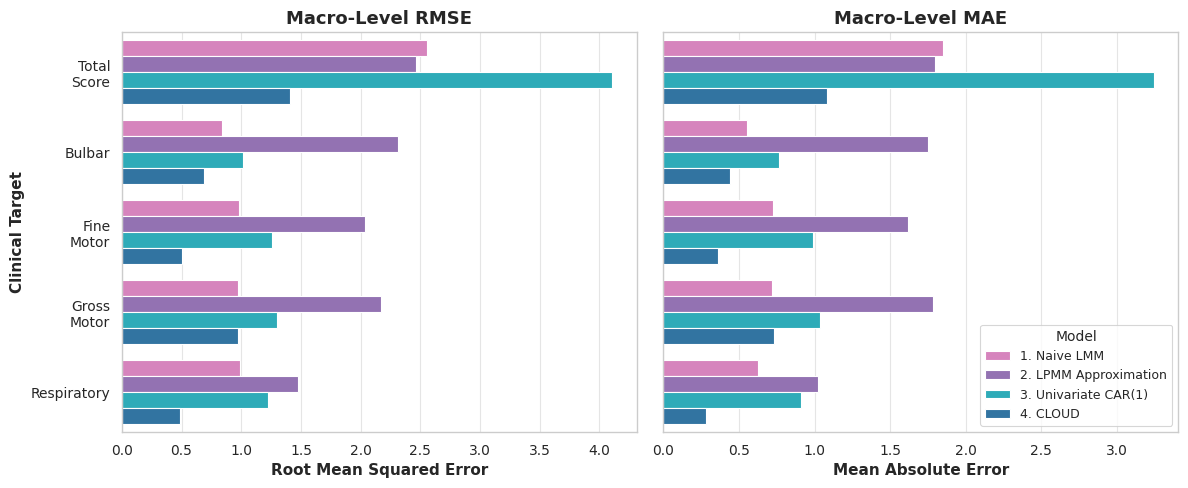

In [3]:
# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

# Enforce a white background with visible grid lines
# sns.set_theme(style="whitegrid")

model_colors = {
    '1. Naive LMM': '#e377c2',          
    '2. LPMM Approximation':'#9467bd',      
    '3. Univariate CAR(1)':'#17becf',  
    '4. CLOUD': '#1f77b4'
}

df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

# Rename targets to use line breaks (\n) for tighter left margins
rename_map = {
    'Total Score': 'Total\nScore',
    'Fine_Motor': 'Fine\nMotor',
    'Gross_Motor': 'Gross\nMotor',
    'Bulbar': 'Bulbar',
    'Respiratory': 'Respiratory'
}
df_macro['Target'] = df_macro['Target'].astype(str).replace(rename_map)

# Re-apply the categorical ordering
target_order = ['Total\nScore', 'Bulbar', 'Fine\nMotor', 'Gross\nMotor', 'Respiratory']
df_macro['Target'] = pd.Categorical(df_macro['Target'], categories=target_order, ordered=True)

# Set base font sizes for publication scaling
plt.rc('axes', titlesize=13, labelsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=9, title_fontsize=10)

# Create a 1x2 grid sharing the Y-axis (Clinical Targets)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

# ==========================================
# Panel A: Macro-Level RMSE (Left)
# ==========================================
sns.barplot(data=df_macro, y='Target', x='RMSE', hue='Model', palette=model_colors, hue_order=mod_order, ax=axes[0])

axes[0].set_title('Macro-Level RMSE', fontweight='bold')
axes[0].set_xlabel('Root Mean Squared Error', fontweight='bold')
axes[0].set_ylabel('Clinical Target', fontweight='bold')

# Ensure gridlines are behind the bars
axes[0].grid(axis='x', linestyle='-', alpha=0.5)
axes[0].set_axisbelow(True)

# Remove the legend from the left plot
axes[0].get_legend().remove()


# ==========================================
# Panel B: Macro-Level MAE (Right)
# ==========================================
sns.barplot(data=df_macro, y='Target', x='MAE', hue='Model', palette=model_colors, hue_order=mod_order, ax=axes[1])

axes[1].set_title('Macro-Level MAE', fontweight='bold')
axes[1].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[1].set_ylabel('') # Clear Y-label since it is shared with Panel A

# Ensure gridlines are behind the bars
axes[1].grid(axis='x', linestyle='-', alpha=0.5)
axes[1].set_axisbelow(True)

# Place the shared legend in the bottom right of Panel B
axes[1].legend(title='Model', loc='lower right')


# Tight layout will neatly compress everything
plt.tight_layout()
save_multiformat('Fig_AB_Macro_Metrics')

print(" -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.")

# # Reset matplotlib rcParams and seaborn theme
# plt.rcdefaults()
# sns.reset_defaults()


Generating Empirical Intuition Plots (Aggregated State vs. Velocity)...


Generated 'Fig_J_Empirical_Interaction_Velocity.png' successfully.


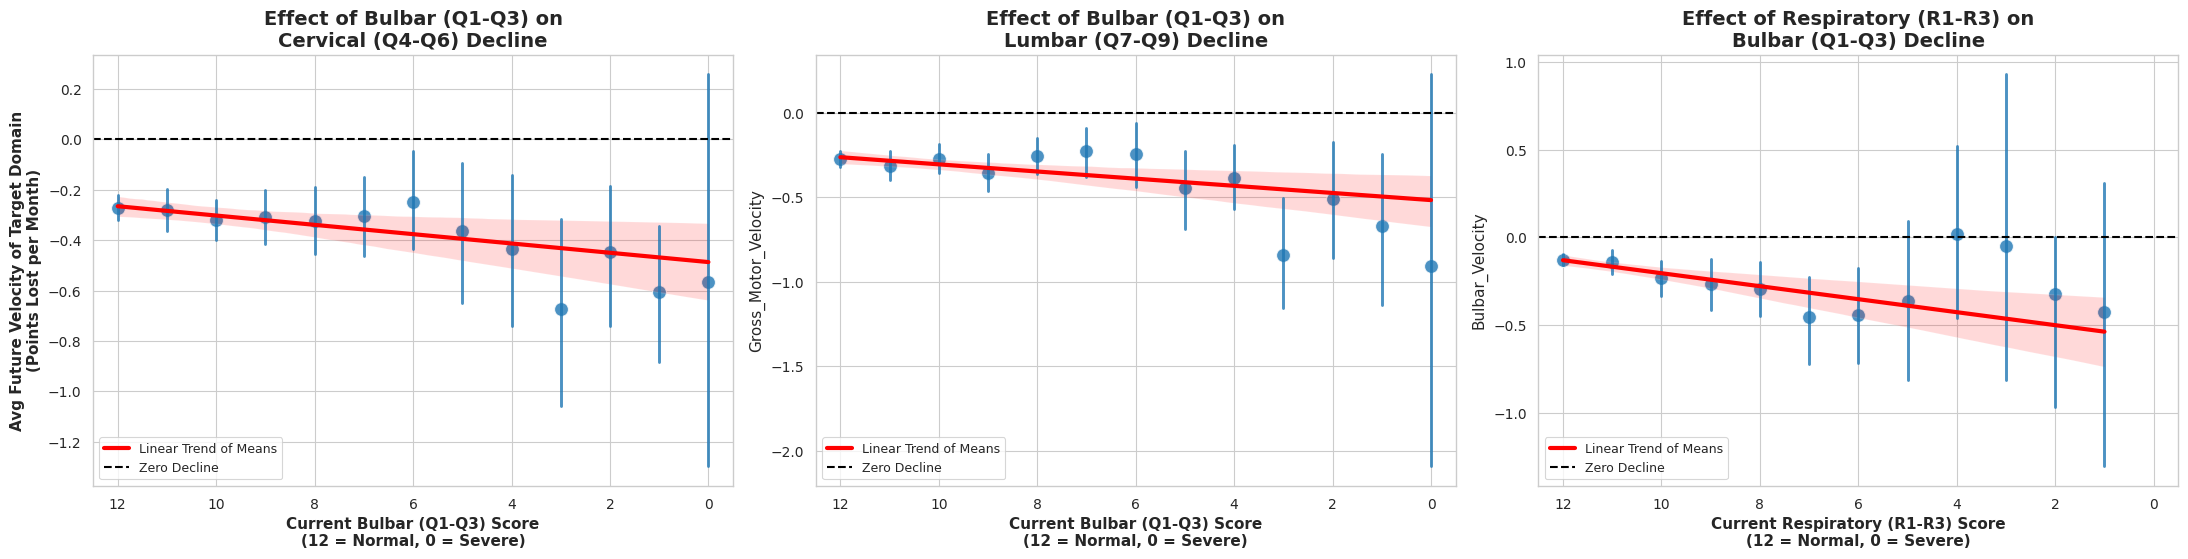

In [4]:
# ==========================================
# 7. EMPIRICAL INTUITION: STATE VS. VELOCITY (V3 - AGGREGATED MEANS)
# ==========================================
print("\nGenerating Empirical Intuition Plots (Aggregated State vs. Velocity)...")

# 1. Map data columns to standard anatomical domain names
domain_map = {
    'Bulbar': 'Bulbar (Q1-Q3)',
    'Fine_Motor': 'Cervical (Q4-Q6)',
    'Gross_Motor': 'Lumbar (Q7-Q9)',
    'Respiratory': 'Respiratory (R1-R3)'  # Fixed labeling
}

df_emp = df.copy()

# Sort by subject and time to ensure sequential differences are correct
df_emp = df_emp.sort_values(by=['subject_id', 'ALSFRS_Delta'])

# Calculate the time to the NEXT visit in days
df_emp['Time_Next'] = df_emp.groupby('subject_id')['ALSFRS_Delta'].shift(-1)
df_emp['Time_Gap_Days'] = df_emp['Time_Next'] - df_emp['ALSFRS_Delta']

# Calculate forward velocities: Points lost per month (30.4 days)
for col, anat_name in domain_map.items():
    df_emp[f'{col}_Next'] = df_emp.groupby('subject_id')[col].shift(-1)
    df_emp[f'{col}_Velocity'] = ((df_emp[f'{col}_Next'] - df_emp[col]) / df_emp['Time_Gap_Days']) * 30.4

# Filter out extreme outliers (e.g., visits closer than 2 weeks or further than 1 year)
df_vel = df_emp.dropna(subset=['Time_Gap_Days']).copy()
df_vel = df_vel[(df_vel['Time_Gap_Days'] >= 14) & (df_vel['Time_Gap_Days'] <= 365)] 

# 2. Plotting the Empirical Interactions
fig_int, axes_int = plt.subplots(1, 3, figsize=(22, 6))
# fig_int.suptitle("Empirical Proof of Interaction: State vs. Expected Clinical Decline Rate", fontweight='bold', fontsize=18)

# Interaction Pairs (Checking if one domain drives the decline of another)
pairs_to_plot = [
    ('Bulbar', 'Fine_Motor'),      # Does Bulbar state affect Cervical decline?
    ('Bulbar', 'Gross_Motor'),     # Does Bulbar state affect Lumbar decline?
    ('Respiratory', 'Bulbar')      # Does Respiratory state affect Bulbar decline?
]

for i, (driver_col, target_col) in enumerate(pairs_to_plot):
    ax = axes_int[i]
    
    x_data = df_vel[driver_col]
    y_data = df_vel[f'{target_col}_Velocity']
    
    # THE FIX: Group by the integer score (0-12) and plot the mean velocity.
    # This cuts through the "zero-change" noise to reveal the true underlying slope.
    sns.regplot(
        x=x_data, y=y_data, ax=ax, 
        x_estimator=np.mean, 
        color='#1f77b4', 
        scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolor': 'white'},
        line_kws={'color': 'red', 'linewidth': 3, 'label': 'Linear Trend of Means'}
    )
    
    # Baseline for zero velocity
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Decline')
    
    # Retrieve correct anatomical names for labels
    driver_name = domain_map[driver_col]
    target_name = domain_map[target_col]
    
    # Formatting (12 = Normal, 0 = Severe)
    ax.set_xlim(12.5, -0.5) 
    ax.set_title(f"Effect of {driver_name} on\n{target_name} Decline", fontweight='bold', fontsize=14)
    ax.set_xlabel(f"Current {driver_name} Score\n(12 = Normal, 0 = Severe)", fontweight='bold')
    
    if i == 0:
        ax.set_ylabel(f"Avg Future Velocity of Target Domain\n(Points Lost per Month)", fontweight='bold')
    
    ax.legend(loc='lower left')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
save_multiformat("Fig_J_Empirical_Interaction_Velocity")
# plt.savefig("Fig_J_Empirical_Interaction_Velocity.png", dpi=300, bbox_inches='tight')
print("Generated 'Fig_J_Empirical_Interaction_Velocity.png' successfully.")


Performing Posterior Predictive Checks (PPCs)...
Generated 'Fig_K_PPC_Distribution.png' successfully.


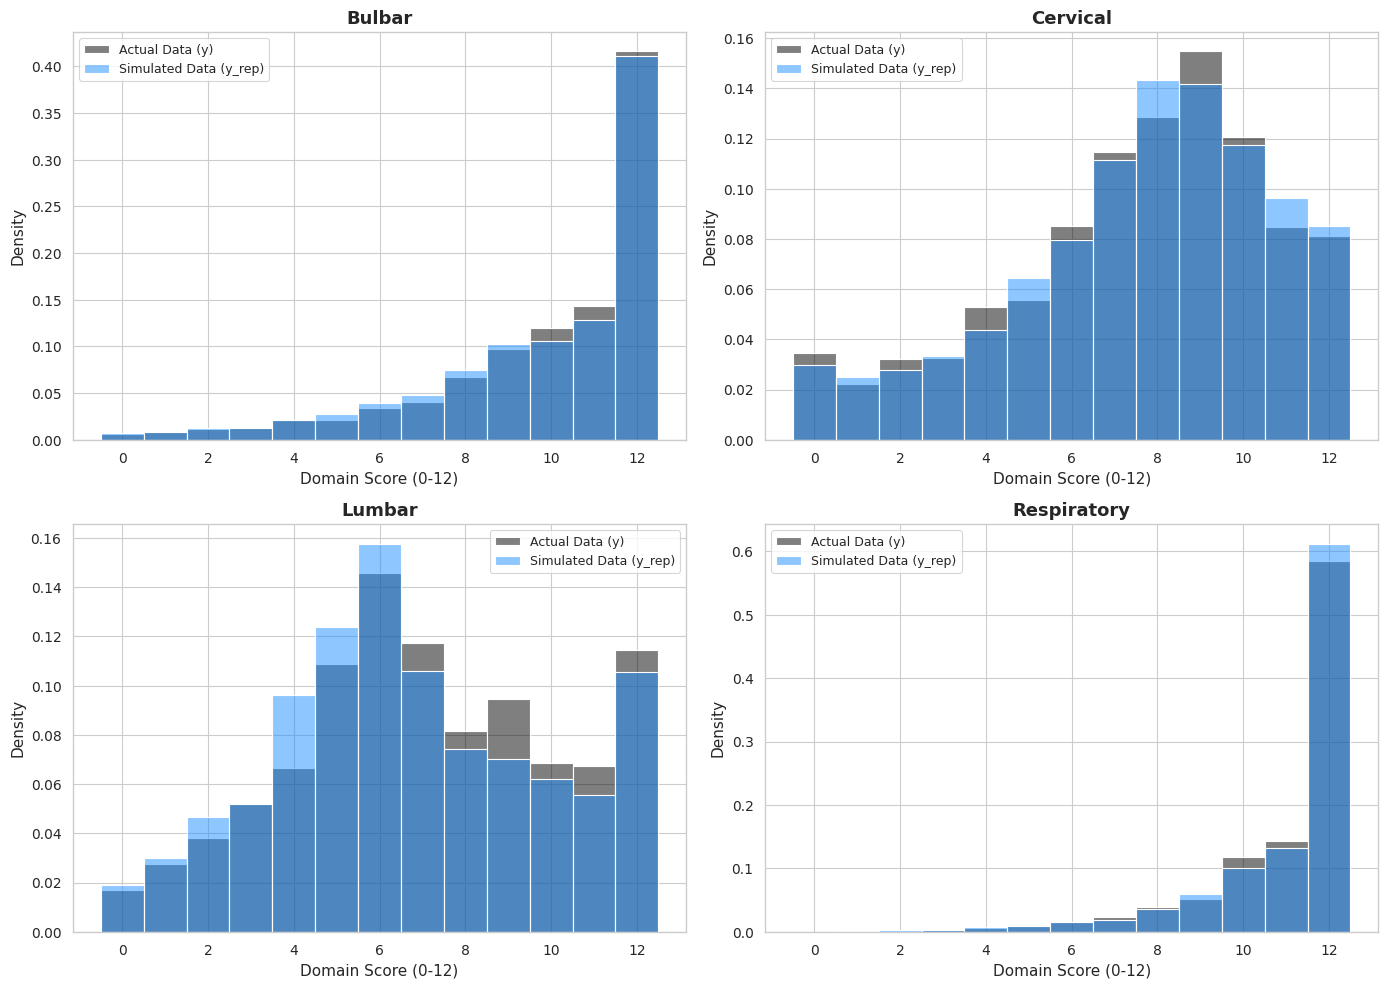

In [5]:
# ==========================================
# 8. POSTERIOR PREDICTIVE CHECKS (PPC) IN PYTHON
# ==========================================
print("\nPerforming Posterior Predictive Checks (PPCs)...")

# We will simulate data using the "Full" model (4a) as an example
model_name = '4. CLOUD' 
df_mcmc = mcmc_dfs[model_name]

# Extract parameters (reusing the safe extraction function from Section 2)
# Note: In a rigorous PPC you sample from the full posterior chain, 
# but simulating from the posterior means (which we have here) provides an excellent proxy.
theta = ext_stan(df_mcmc, 'theta', (12, 4))
lam   = ext_stan(df_mcmc, 'lambda', (12,))
beta  = ext_stan(df_mcmc, 'beta', (12, 3))
xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))

# Matrix to hold our simulated categorical data
sim_sc = np.zeros((len(df), 12))

# 1. Simulate the Data
for i in range(len(df)):
    for d, items in domain_idx_full.items():
        for k in items:
            # Linear predictor
            eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
            
            # Cumulative probabilities
            p = [expit(1.0 * (eta - th)) for th in theta[k]]
            
            # Discrete category probabilities (must sum to 1)
            p_cat = [1.0-p[0], p[0]-p[1], p[1]-p[2], p[2]-p[3], p[3]]
            
            # Ensure no negative rounding errors and normalize
            p_cat = np.clip(p_cat, 0, 1)
            p_cat = p_cat / np.sum(p_cat)
            
            # Draw a random discrete score (0, 1, 2, 3, or 4) based on those probabilities
            sim_sc[i,k] = np.random.choice([0, 1, 2, 3, 4], p=p_cat)

# 2. Generate PPC Plot (Real vs Simulated Distributions)
# Changed to a 2x2 layout and adjusted figsize for better proportions
fig_ppc, axes_ppc = plt.subplots(2, 2, figsize=(14, 10))
# fig_ppc.suptitle(f"Posterior Predictive Check: Actual vs. Simulated Clinical Scores of CLOUD model", fontweight='bold', fontsize=16)

# Flatten the 2x2 array of axes into a 1D array so we can easily index it with 'd' (0, 1, 2, 3)
axes_flat = axes_ppc.flatten()

# Map domains back to standard names
domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for d, items in domain_idx_full.items():
    ax = axes_flat[d]  # Use the flattened axes array
    
    # Sum the real items for this domain
    real_domain_scores = actual_sc[:, items].sum(axis=1)
    
    # Sum the simulated items for this domain
    sim_domain_scores = sim_sc[:, items].sum(axis=1)
    
    # Plot overlapping distributions
    sns.histplot(real_domain_scores, bins=13, discrete=True, color='black', alpha=0.5, label='Actual Data (y)', stat='density', ax=ax)
    sns.histplot(sim_domain_scores, bins=13, discrete=True, color='dodgerblue', alpha=0.5, label='Simulated Data (y_rep)', stat='density', ax=ax)
    
    ax.set_title(domain_labels[d], fontweight='bold')
    ax.set_xlabel("Domain Score (0-12)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
save_multiformat("Fig_K_PPC_Distribution")
print("Generated 'Fig_K_PPC_Distribution.png' successfully.")


Generating Individual-Level Predictive Fits (Trellis Plot)...


Generated 'Fig_R_Individual_Personalized_Fits.png' successfully.


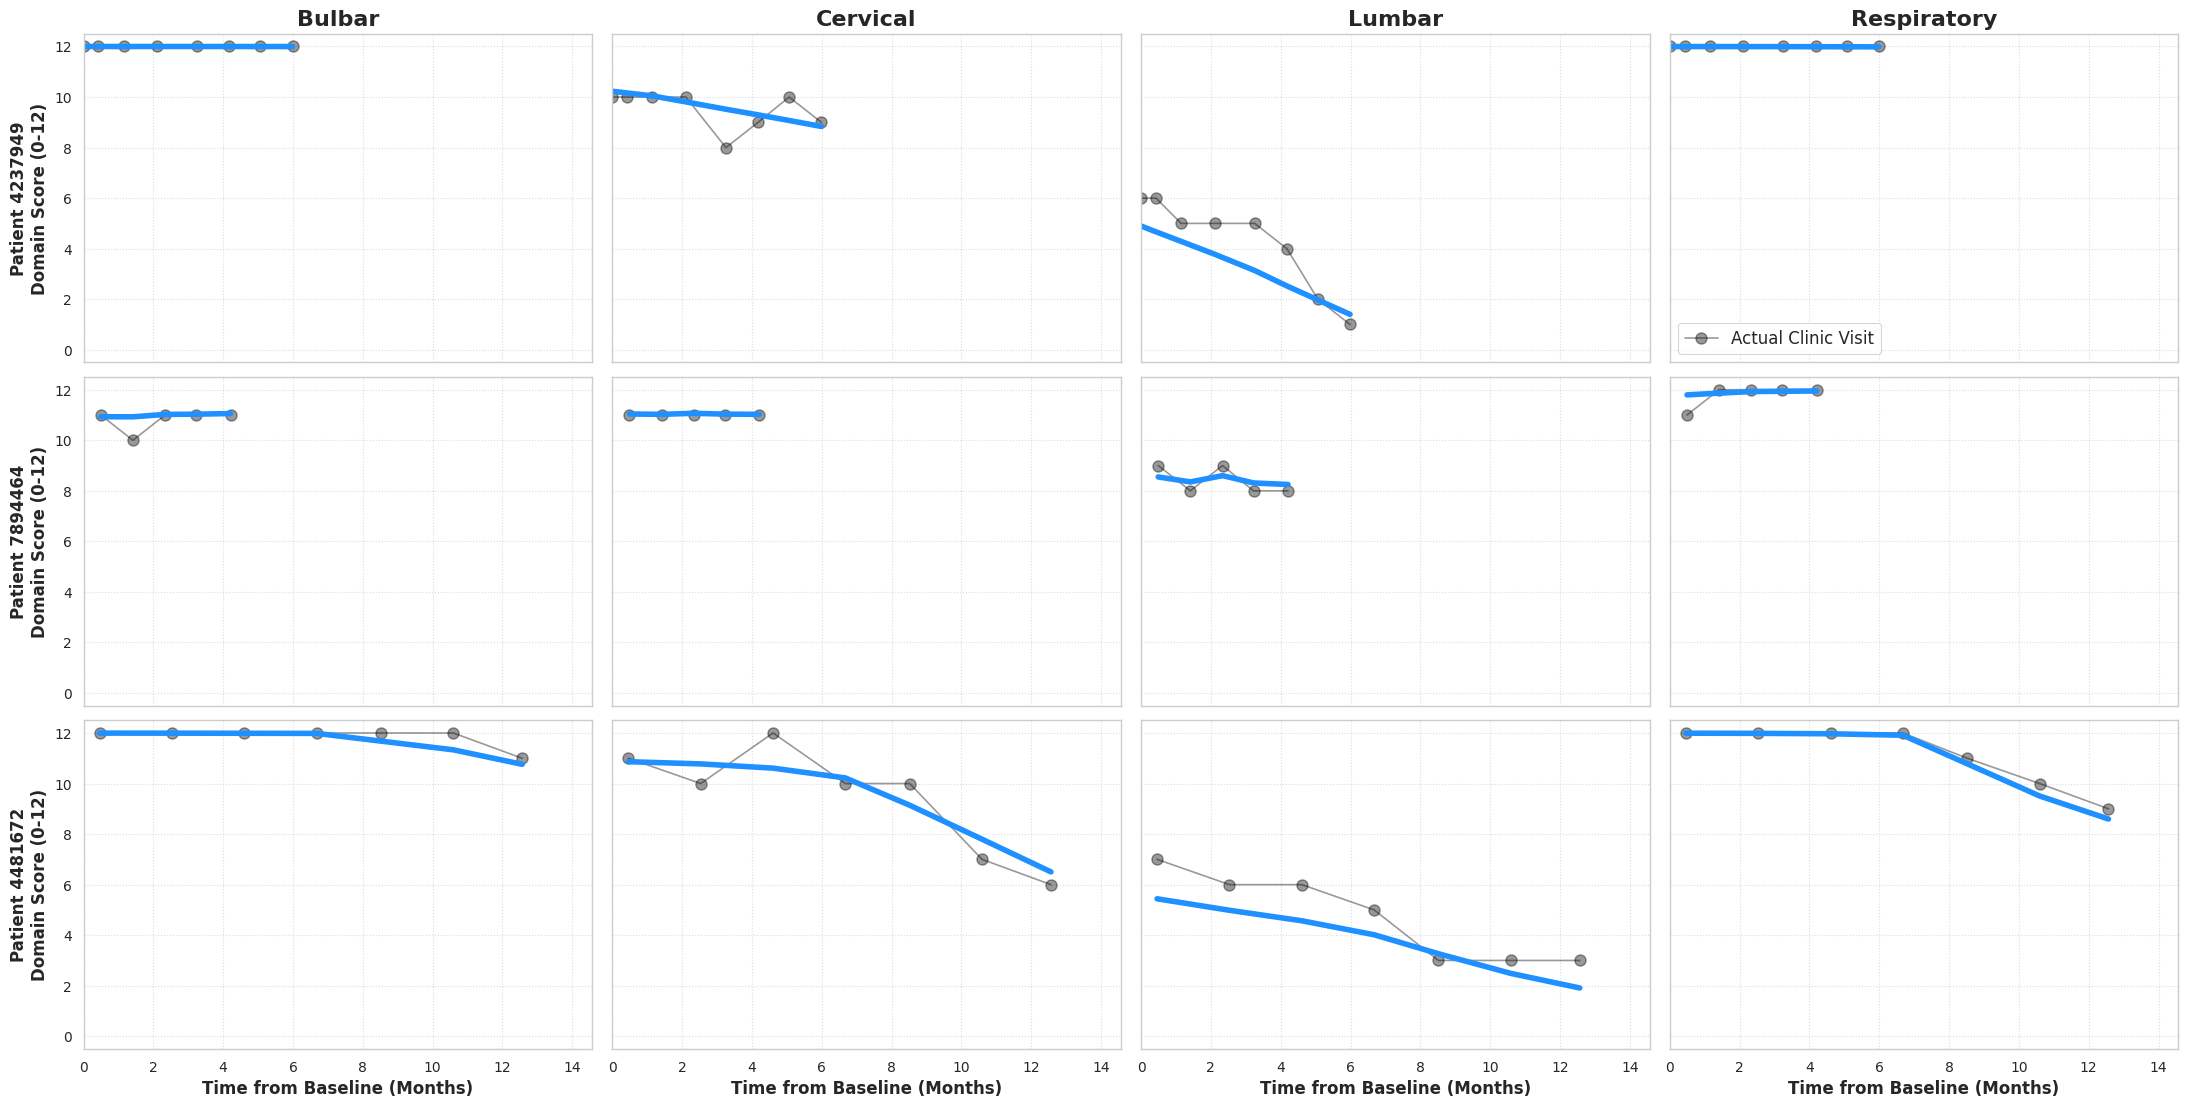

In [6]:
# ==========================================
# 13. INDIVIDUAL-LEVEL LONGITUDINAL FIT (Personalized Predictions)
# ==========================================
print("\nGenerating Individual-Level Predictive Fits (Trellis Plot)...")
df = pd.read_csv(DATA_FILE)
# 1. Find patients with a rich longitudinal history (e.g., at least 5 clinic visits)
visit_counts = df['subject_id'].value_counts()
long_term_patients = visit_counts[visit_counts >= 5].index

# Randomly sample 3 patients for the visualization
np.random.seed(86) # For reproducible patient selection
sample_pats = np.random.choice(long_term_patients, size=3, replace=False)

# Setup a 3x4 Grid (3 Patients x 4 Domains)
fig_ind, axes_ind = plt.subplots(3, 4, figsize=(22, 12), sharex=True, sharey=True)
# fig_ind.suptitle("Personalized Medicine in Action: CLOUD Model vs. Actual Individual Patient Trajectories", fontweight='bold', fontsize=20)

domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for row_idx, pat_id in enumerate(sample_pats):
    # Find all rows in the dataframe for this specific patient
    pat_mask = (df['subject_id'] == pat_id)
    pat_time = df.loc[pat_mask, 'ALSFRS_Delta'].values / 30.4
    
    for d, items in domain_idx_full.items():
        ax = axes_ind[row_idx, d]
        dom_name = domain_labels[d]
        
        # Extract Actual Domain Scores for this patient
        y_actual = actual_sc[pat_mask][:, items].sum(axis=1)
        
        # Extract CLOUD's Expected Domain Scores for this patient
        y_pred = exp_sc[pat_mask][:, items].sum(axis=1)
        
        # Plot Actual Data (Black dots connected by a faint grey line)
        ax.plot(pat_time, y_actual, marker='o', markersize=8, color='black', linestyle='-', alpha=0.4, label='Actual Clinic Visit')
        
        # Plot CLOUD Prediction (Thick blue line)
        # We use a slight smoothing here just to connect the discrete prediction points elegantly
        sns.regplot(
            x=pat_time, 
            y=y_pred, 
            scatter=False, 
            lowess=True, 
            color='dodgerblue', 
            line_kws={'linewidth': 4, 'label': 'CLOUD Personalized Prediction'}, 
            ax=ax
        )
        
        # Formatting
        if row_idx == 0:
            ax.set_title(dom_name, fontweight='bold', fontsize=16)
        
        if d == 0:
            ax.set_ylabel(f"Patient {pat_id}\nDomain Score (0-12)", fontweight='bold', fontsize=12)
        else:
            ax.set_ylabel("")
            
        if row_idx == 2:
            ax.set_xlabel("Time from Baseline (Months)", fontweight='bold', fontsize=12)
        else:
            ax.set_xlabel("")
            
        ax.set_xlim(0, max(pat_time) + 2) # Add a little padding to the right
        ax.set_ylim(-0.5, 12.5)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        # Only add the legend to the top-right plot
        if row_idx == 0 and d == 3:
            ax.legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
save_multiformat("Fig_R_Individual_Personalized_Fits")
# plt.savefig("Fig_R_Individual_Personalized_Fits.png", dpi=300, bbox_inches='tight')
print("Generated 'Fig_R_Individual_Personalized_Fits.png' successfully.")


Generating Empirical Motivation Plots (Domain-Level Progression)...


Generated 'Fig_M_Empirical_Domain_Covariates' successfully.


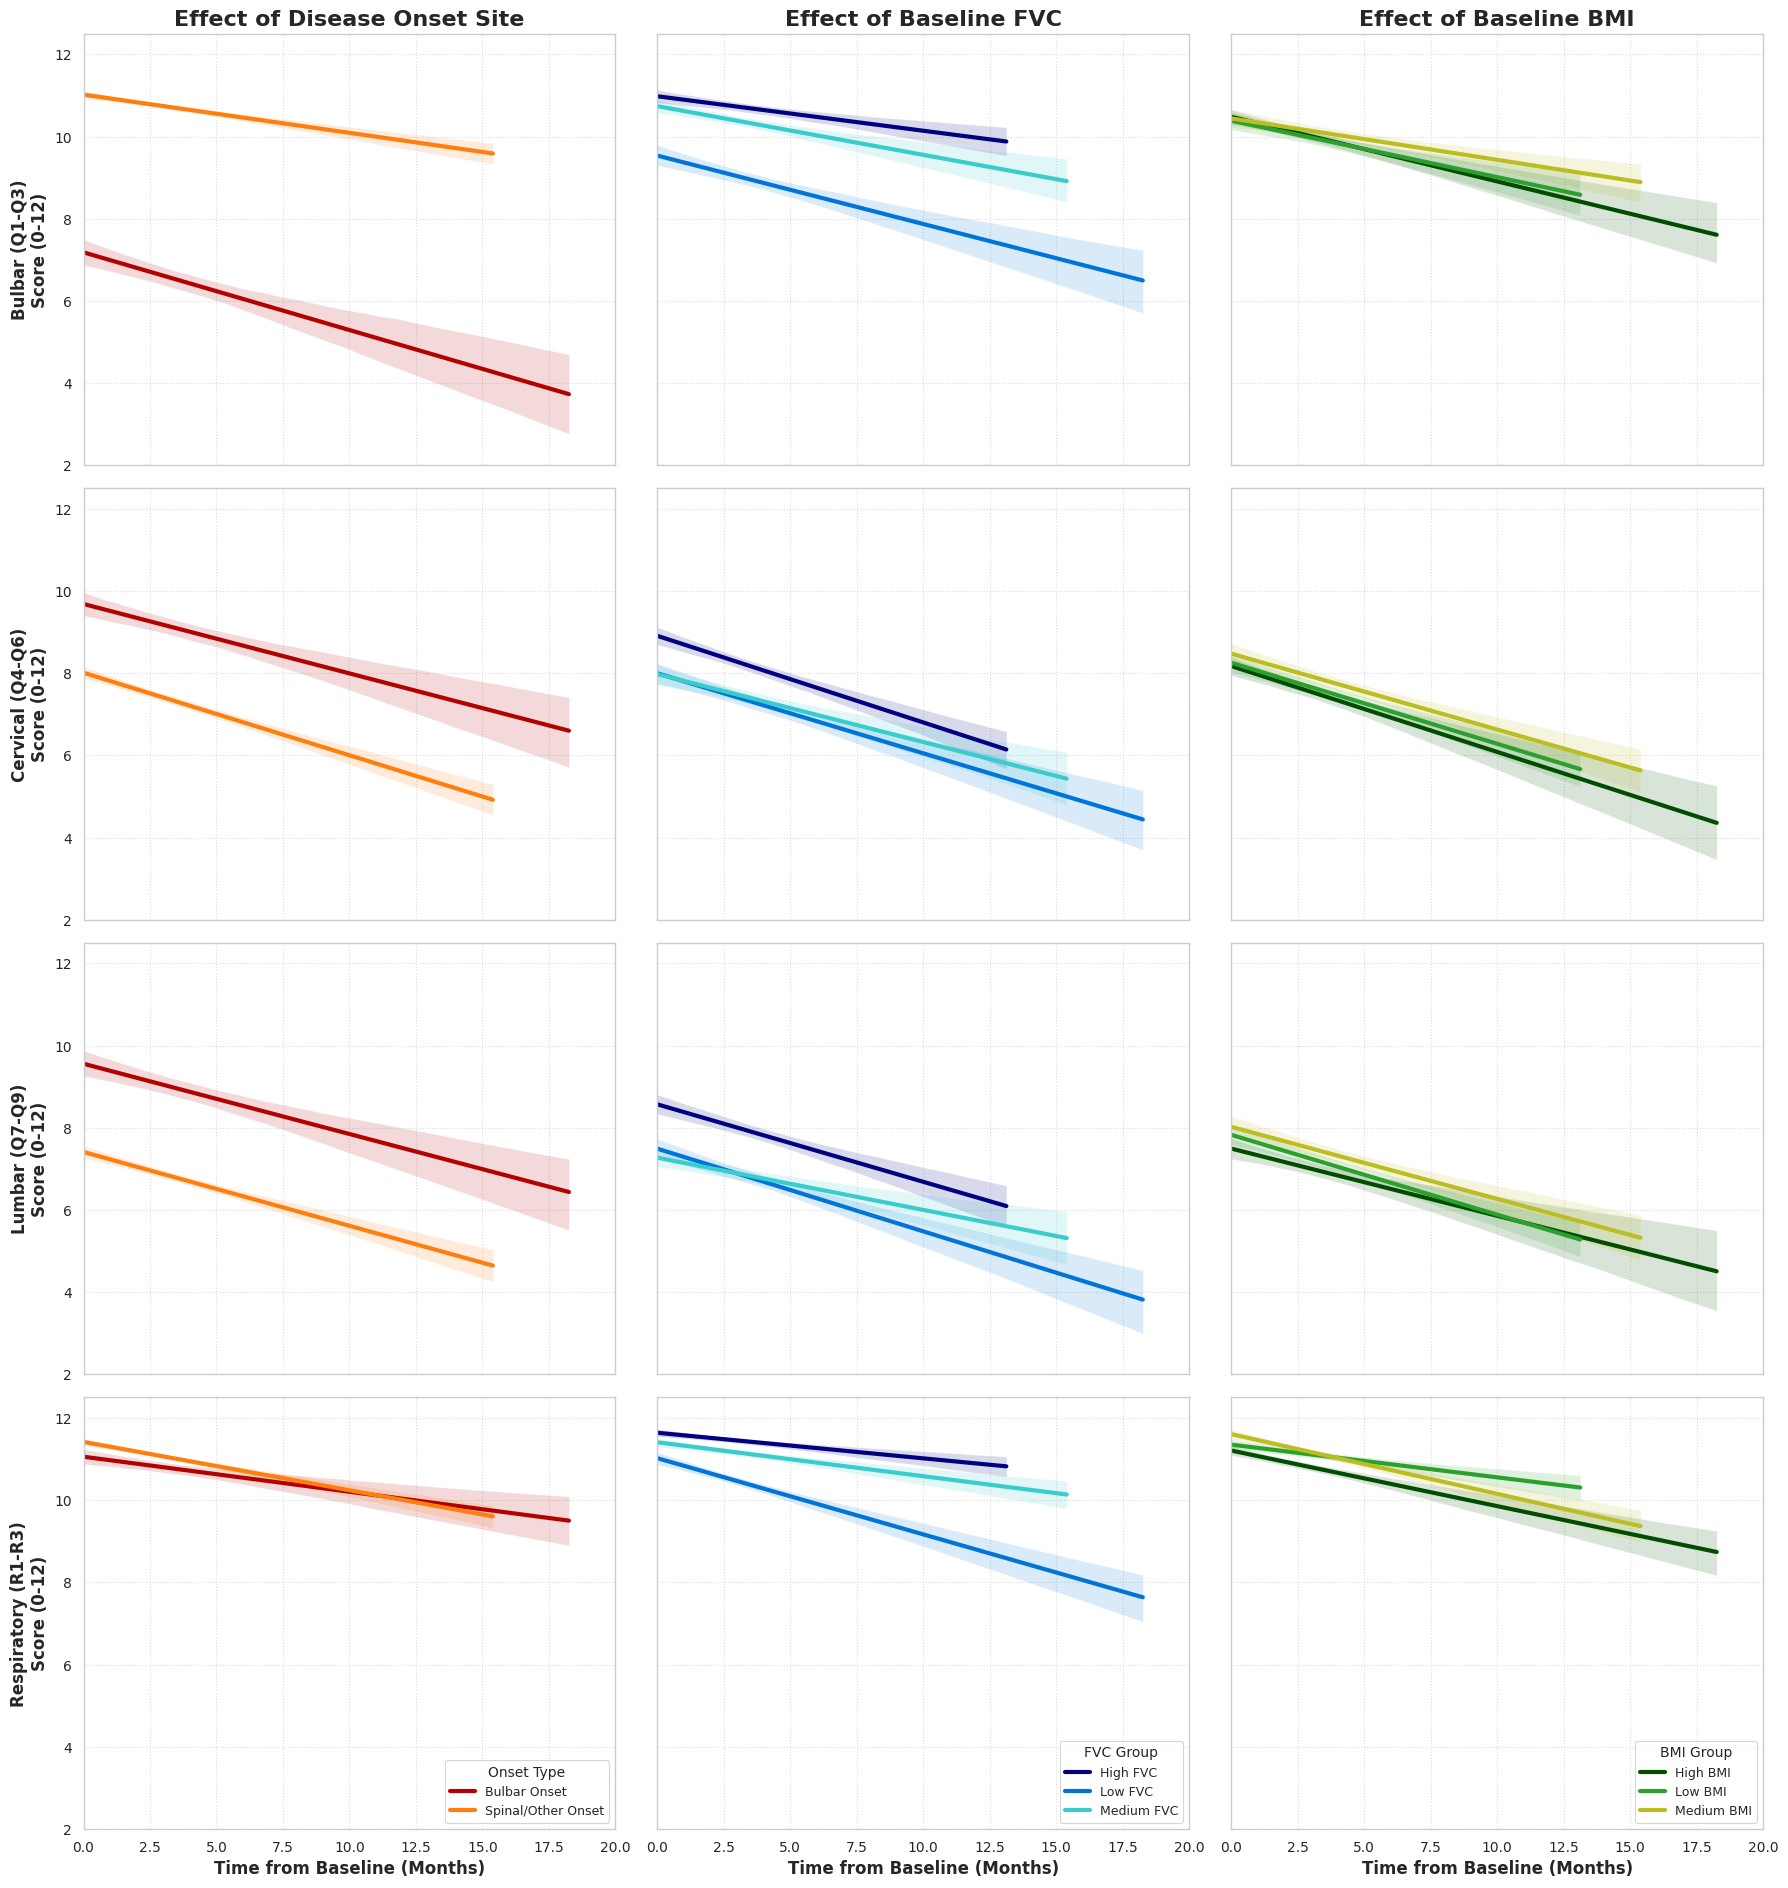

In [7]:
# ==========================================
# 8. EMPIRICAL MOTIVATION: COVARIATES VS. DOMAIN-LEVEL PROGRESSION
# ==========================================
print("\nGenerating Empirical Motivation Plots (Domain-Level Progression)...")

df_mot = df.copy()

# Convert time from Days to Months for intuitive X-axis scaling
df_mot['Time_Months'] = df_mot['ALSFRS_Delta'] / 30.4

# Filter out extreme long-tails (e.g., beyond 20 months)
df_mot = df_mot[df_mot['Time_Months'] <= 20]

# 1. Stratify Continuous Covariates into Tertiles (Low, Medium, High)
df_mot['FVC_Group'] = pd.qcut(df_mot['FVC_Base'], q=3, labels=['Low FVC', 'Medium FVC', 'High FVC'])
df_mot['BMI_Group'] = pd.qcut(df_mot['BMI_Base'], q=3, labels=['Low BMI', 'Medium BMI', 'High BMI'])

# Map Bulbar Onset to readable labels
df_mot['Onset_Type'] = df_mot['Bulbar_Onset'].map({1.0: 'Bulbar Onset', 0.0: 'Spinal/Other Onset'})

# 1.5 Calculate the aggregate Domain Scores
df_mot['Bulbar'] = df_mot[['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing']].sum(axis=1)
df_mot['Fine_Motor'] = df_mot[['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene']].sum(axis=1)
df_mot['Gross_Motor'] = df_mot[['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs']].sum(axis=1)
df_mot['Respiratory'] = df_mot[['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']].sum(axis=1)

# Define the targets (Now the ROWS in the grid)
domain_targets = {
    'Bulbar': 'Bulbar (Q1-Q3)',
    'Fine_Motor': 'Cervical (Q4-Q6)',
    'Gross_Motor': 'Lumbar (Q7-Q9)',
    'Respiratory': 'Respiratory (R1-R3)'
}

# Define the covariates (Now the COLUMNS in the grid)
covariate_configs = [
    {'col': 'Onset_Type', 'title': 'Effect of Disease Onset Site', 'palette': ['#b30000', '#ff7f0e']},
    {'col': 'FVC_Group', 'title': 'Effect of Baseline FVC', 'palette': ['#000080', '#0074D9', '#39CCCC']},
    {'col': 'BMI_Group', 'title': 'Effect of Baseline BMI', 'palette': ['#004d00', '#2ca02c', '#bcbd22']}
]

# 2. Setup the 4x3 Visualization Grid (4 Domains x 3 Covariates)
fig_cov, axes_cov = plt.subplots(4, 3, figsize=(18, 20), sharex=True, sharey=True)
# fig_cov.suptitle("Domain-Level Empirical Motivation: How Covariates Alter Specific Progression Rates", fontweight='bold', fontsize=20)

# Loop over Domains (Rows) first, then Covariates (Columns)
for row_idx, (dom_col, dom_name) in enumerate(domain_targets.items()):
    for col_idx, config in enumerate(covariate_configs):
        
        ax = axes_cov[row_idx, col_idx]
        group_col = config['col']
        groups = df_mot[group_col].dropna().unique()
        
        # Handle color palettes dynamically
        if isinstance(config['palette'], list):
            colors = config['palette']
        else:
            colors = sns.color_palette(config['palette'], n_colors=len(groups))
            
        for idx, group_val in enumerate(sorted(groups)):
            subset = df_mot[df_mot[group_col] == group_val]
            
            sns.regplot(
                x='Time_Months', 
                y=dom_col, 
                data=subset, 
                ax=ax, 
                scatter=False, 
                color=colors[idx],
                label=str(group_val),
                line_kws={'linewidth': 3}
            )
            
        # --- Formatting titles and labels for transposed grid ---
        
        # Column Titles (Covariates) go on the top row
        if row_idx == 0:
            ax.set_title(config['title'], fontweight='bold', fontsize=16)
            
        # Y-Axis Labels (Domains) go on the left column
        if col_idx == 0:
            ax.set_ylabel(f"{dom_name}\nScore (0-12)", fontweight='bold', fontsize=12)
        else:
            ax.set_ylabel("")
            
        # X-Axis Labels go on the bottom row (row_idx == 3)
        if row_idx == 3:
            ax.set_xlabel("Time from Baseline (Months)", fontweight='bold', fontsize=12)
            # Add one legend per column at the bottom to identify the covariates
            ax.legend(title=group_col.replace('_', ' '), loc='lower right')
        else:
            ax.set_xlabel("")
            
        ax.set_xlim(0, 20)
        ax.set_ylim(2, 12.5) 
        ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.93) 
save_multiformat("Fig_M_Empirical_Domain_Covariates")
print("Generated 'Fig_M_Empirical_Domain_Covariates' successfully.")


Generating Comprehensive Longitudinal Validation Plot...


Generated 'Fig_S_Combined_Longitudinal_Overview' successfully.


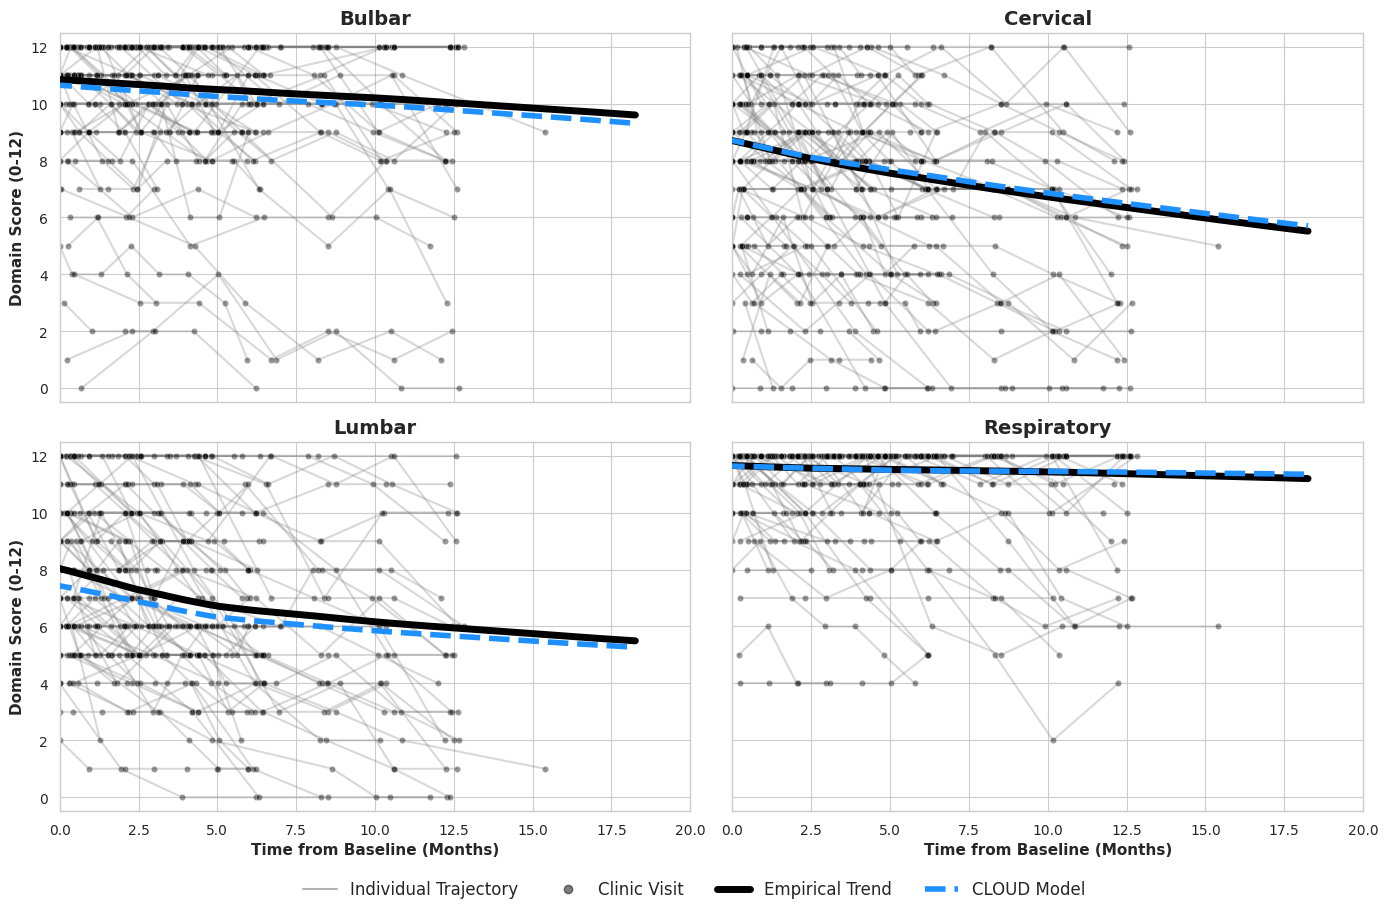

In [8]:
# ==========================================
# 12. COMPREHENSIVE LONGITUDINAL VALIDATION (WITH MASTER LEGEND)
# ==========================================
print("\nGenerating Comprehensive Longitudinal Validation Plot...")

import matplotlib.lines as mlines

# 1. Prep the time variable and mask for the 20-month window
time_months = df['ALSFRS_Delta'].values / 30.4
valid_idx = time_months <= 20

# 2. Sample 100 patients for the "Spaghetti" background
np.random.seed(42)
sample_subjects = np.random.choice(df.loc[valid_idx, 'subject_id'].unique(), size=100, replace=False)

# 2x2 layout with optimized height (14, 10)
fig_combo, axes_combo = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True) 

# FINAL TUNE 1: Lower the title to 93.1% (almost touching the subplot boundary)
# fig_combo.suptitle("Comprehensive Longitudinal Validation: Individual Chaos vs. Model Trajectory", fontweight='bold', fontsize=18, y=0.931)

# Flatten the 2x2 axes grid to a 1D array of 4 elements for easy indexing
axes_flat = axes_combo.flatten()

domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for d, items in domain_idx_full.items():
    ax = axes_flat[d]
    dom_name = domain_labels[d]
    
    # Extract Actual and Predicted Scores for ALL patients
    actual_dom_all = actual_sc[:, items].sum(axis=1)
    pred_dom_all = exp_sc[:, items].sum(axis=1)
    
    # Create a dataframe for the LOESS curves (ALL data)
    df_all = pd.DataFrame({
        'subject_id': df['subject_id'],
        'Time_Months': time_months,
        'Actual_Score': actual_dom_all,
        'Predicted_Score': pred_dom_all
    })
    df_all_valid = df_all[valid_idx]
    
    # Create a sub-dataframe for the Spaghetti plots (SAMPLED data)
    df_sample = df_all_valid[df_all_valid['subject_id'].isin(sample_subjects)]
    
    # --- LAYER 1: The Raw Individual Lines (Spaghetti) ---
    sns.lineplot(
        data=df_sample, x='Time_Months', y='Actual_Score', units='subject_id', estimator=None,
        color='gray', alpha=0.3, linewidth=1.5, ax=ax, zorder=1
    )
    
    # --- LAYER 2: The Raw Clinic Visits (Scatter) ---
    sns.scatterplot(
        data=df_sample, x='Time_Months', y='Actual_Score',
        color='black', alpha=0.4, s=20, ax=ax, zorder=2
    )
    
    # --- LAYER 3: The True Population Mean (Solid Black Line) ---
    sns.regplot(
        data=df_all_valid, x='Time_Months', y='Actual_Score', scatter=False, lowess=True, 
        color='black', line_kws={'linewidth': 5, 'zorder': 4}, ax=ax
    )
    
    # --- LAYER 4: The Model's Predicted Mean (Dashed Blue Line) ---
    sns.regplot(
        data=df_all_valid, x='Time_Months', y='Predicted_Score', scatter=False, lowess=True, 
        color='dodgerblue', line_kws={'linewidth': 4, 'linestyle': '--', 'zorder': 5}, ax=ax
    )

    ax.set_title(dom_name, fontweight='bold', fontsize=14)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.5, 12.5)

    # Label X-axis only on the bottom row (indices 2 and 3)
    if d >= 2:
        ax.set_xlabel("Time from Baseline (Months)", fontweight='bold')
    else:
        ax.set_xlabel("")

    # Label Y-axis only on the left column (indices 0 and 2)
    if d % 2 == 0:
        ax.set_ylabel("Domain Score (0-12)", fontweight='bold')
    else:
        ax.set_ylabel("")

# --- BUILD THE MASTER LEGEND ---
legend_elements = [
    mlines.Line2D([], [], color='gray', alpha=0.6, linewidth=1.5, label='Individual Trajectory'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', alpha=0.5, markersize=6, label='Clinic Visit'),
    mlines.Line2D([], [], color='black', linewidth=5, label='Empirical Trend'),
    mlines.Line2D([], [], color='dodgerblue', linewidth=4, linestyle='--', label='CLOUD Model')
]

# PUBLICATION FORMATTING: Single horizontal line, no box, placed at the very bottom.
fig_combo.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.01), # Centered, slightly above the bottom edge of the figure canvas
    ncol=4,                     # Spreads the 4 items into a single row
    fontsize=12, 
    frameon=False               # Removes the bounding box/shadow (crucial for publication style)
)

# FINAL TUNE 2: Keep the top bound of the subplots at 93% 
# Boundaries defined as: rect=[left, bottom, right, top]
plt.tight_layout(rect=[0, 0.05, 1, 0.93]) 

save_multiformat("Fig_S_Combined_Longitudinal_Overview")
print("Generated 'Fig_S_Combined_Longitudinal_Overview' successfully.")

# Web Appendix

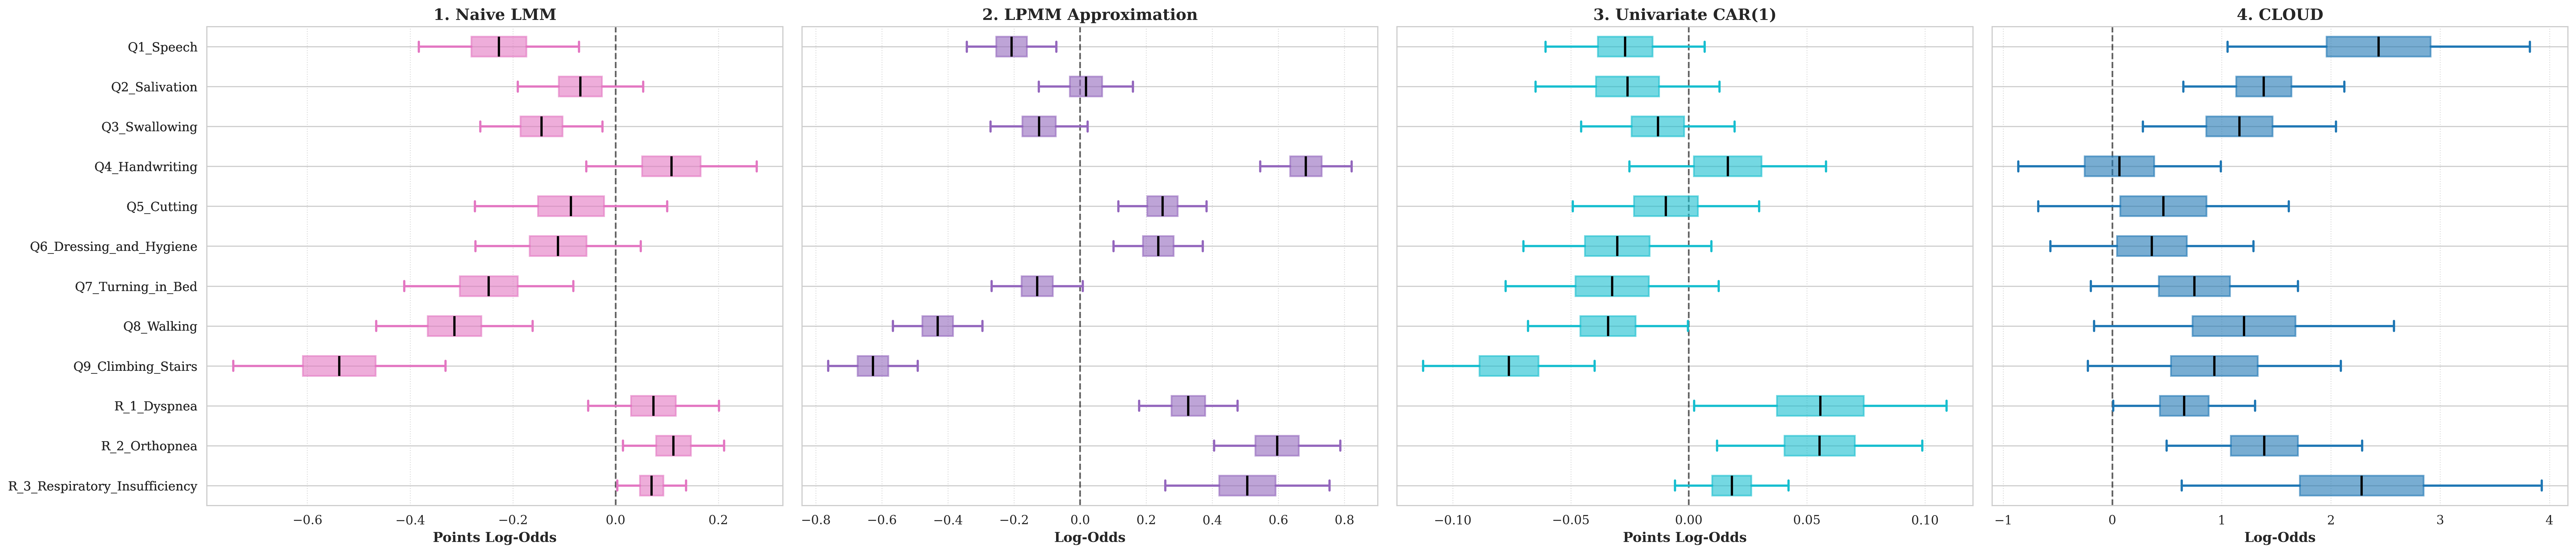

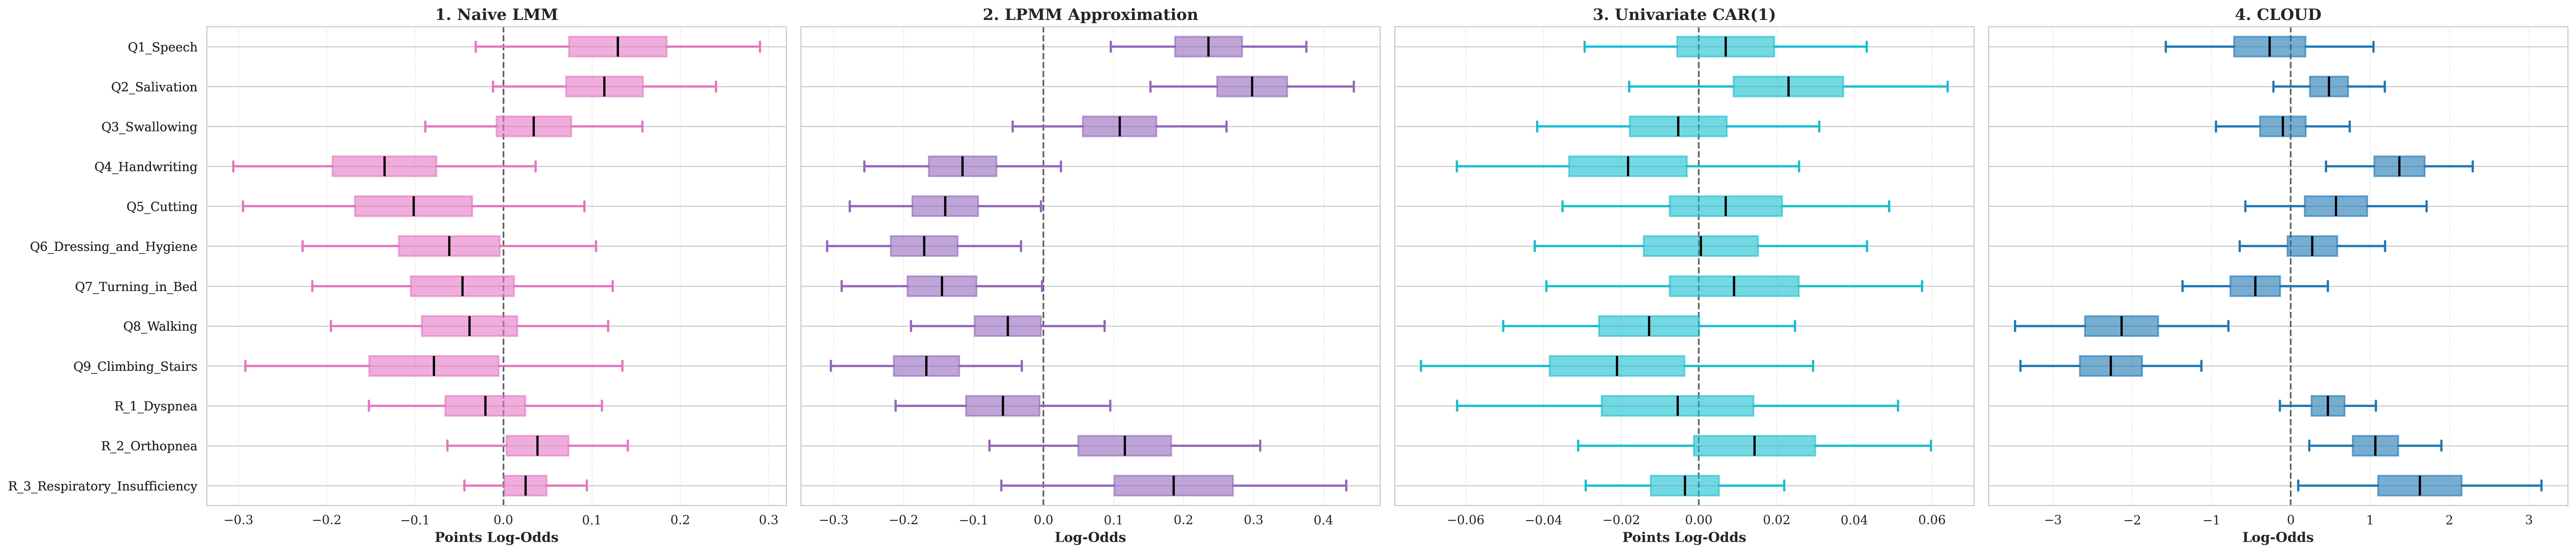

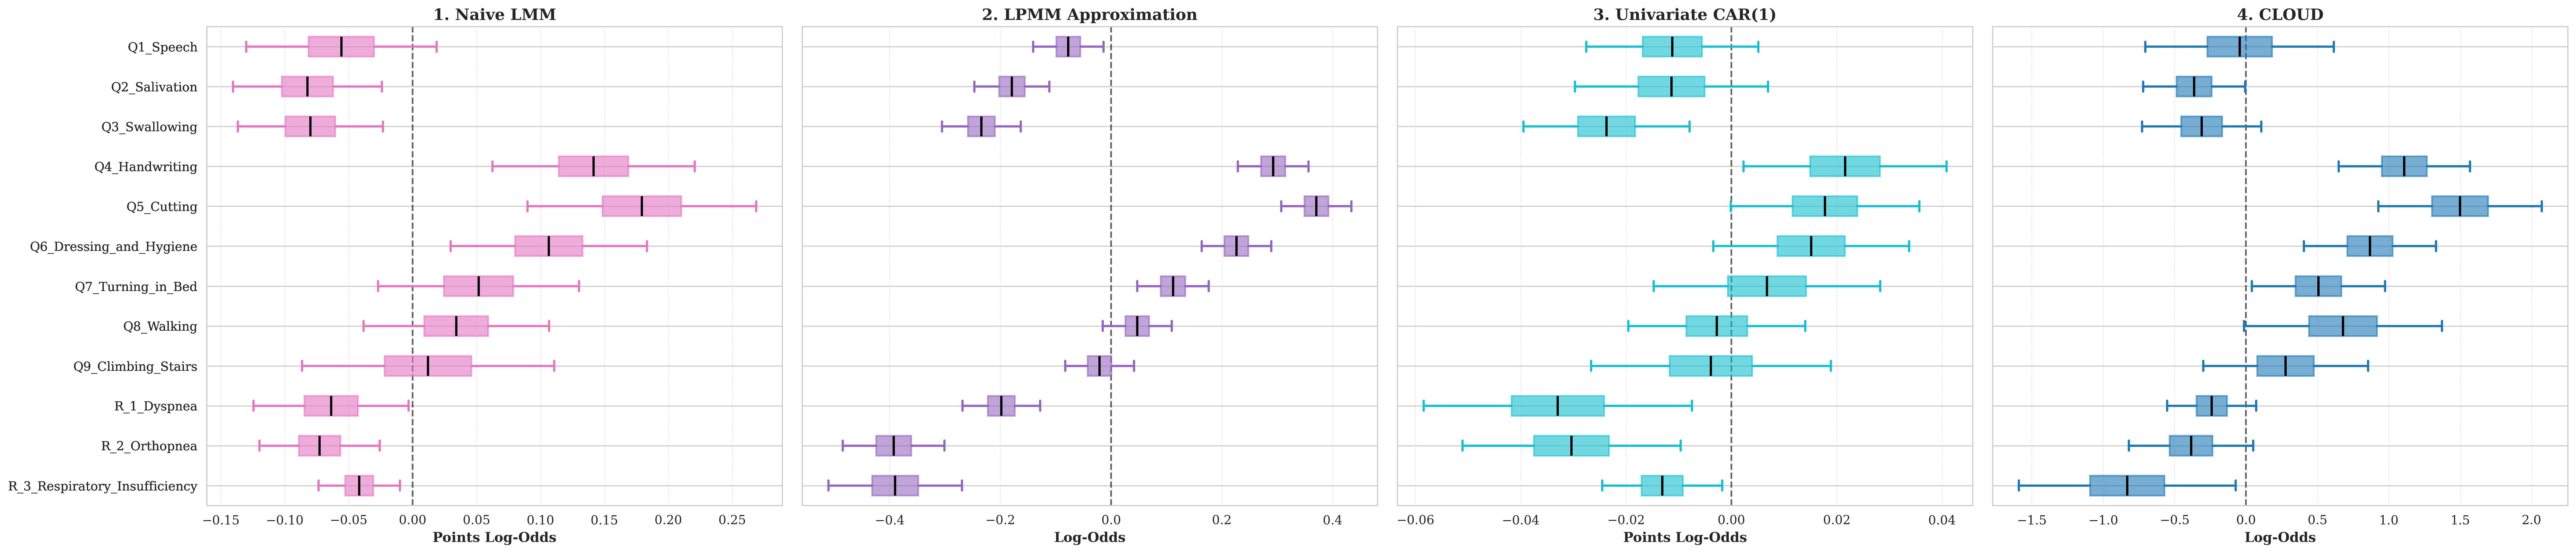

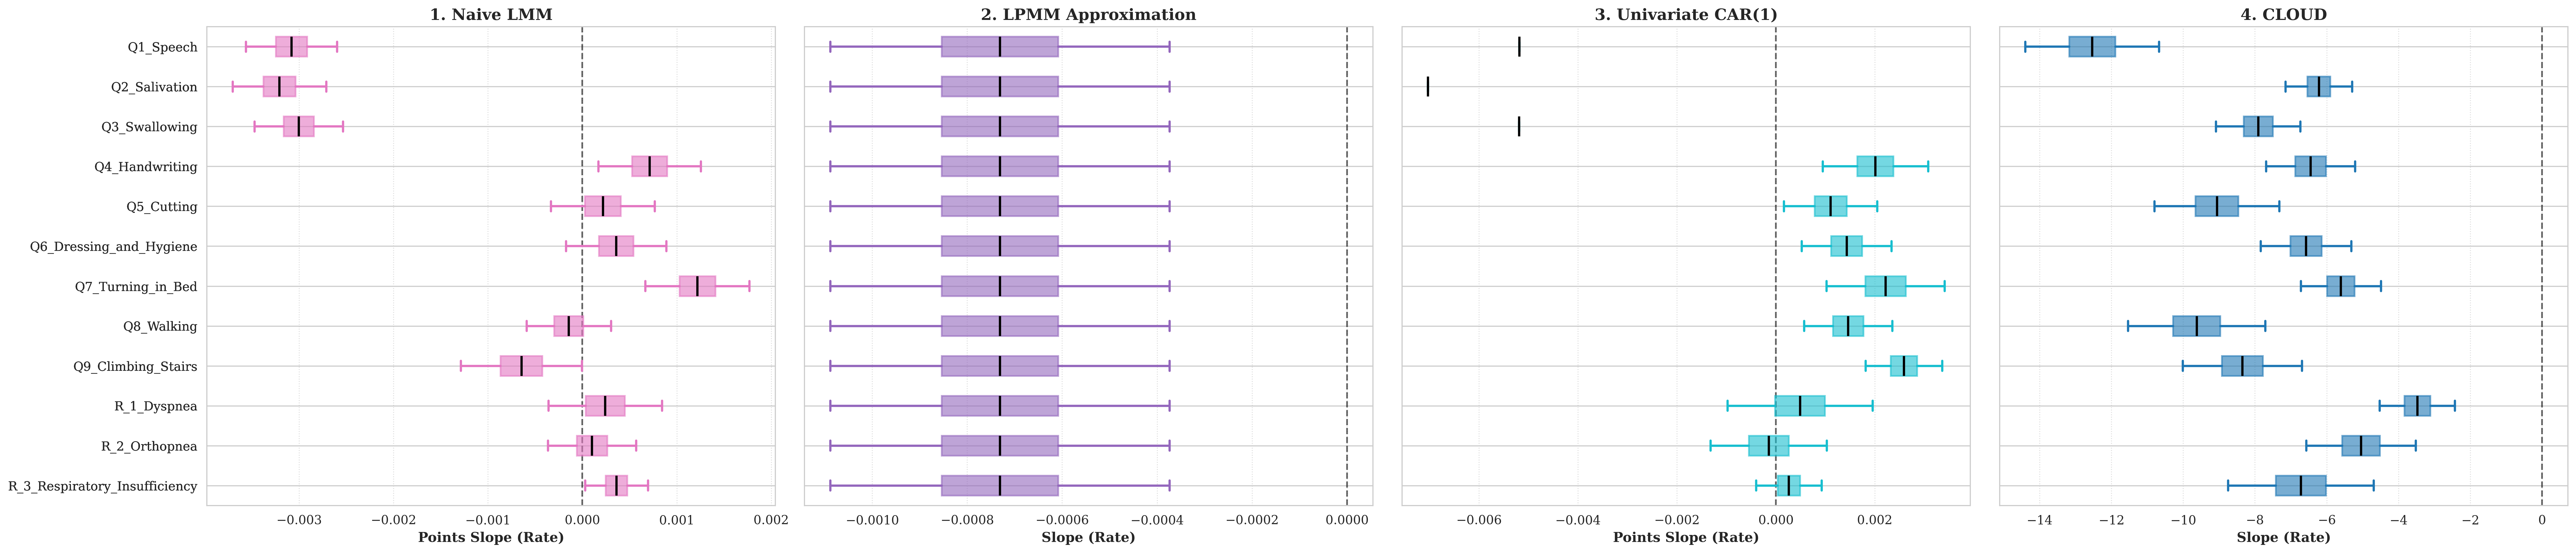

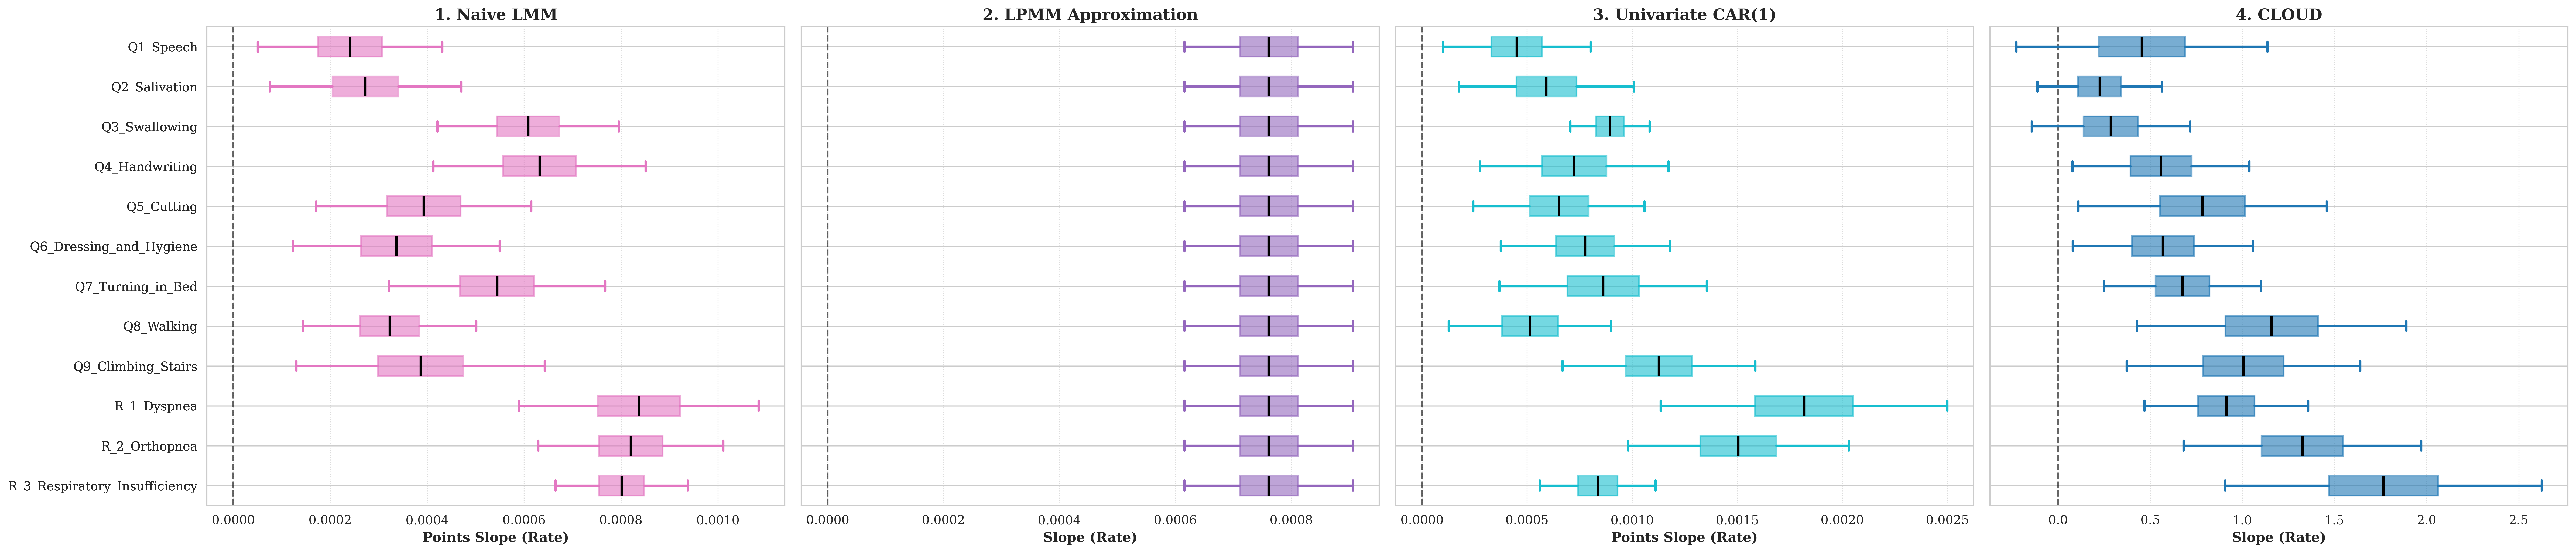

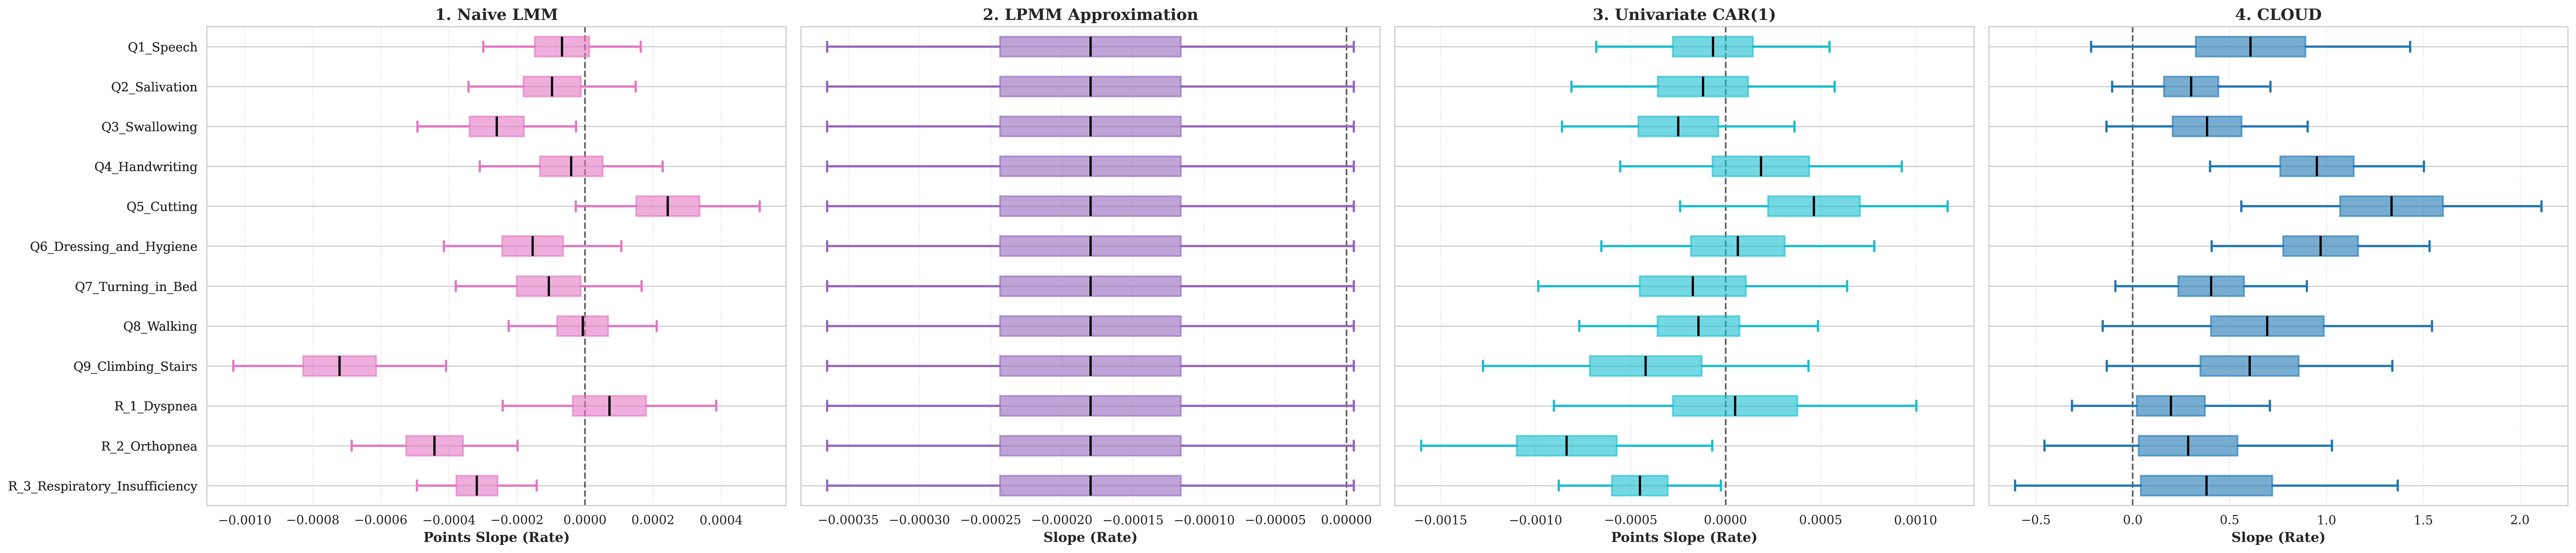

In [13]:
import matplotlib.pyplot as plt

# Plot D: Forest Plots (Box Plot Style)
for cov in all_covariates:
    subset = df_covs[df_covs['Covariate'] == cov]
    fig, axes = plt.subplots(1, 4, figsize=(32, 7), sharey=True)
    # fig.suptitle(f"Forest Plot: {cov} Across 4 Models", fontweight='bold', fontsize=16)
    
    base_unit = "Log-Odds" if cov in meas_covariates else "Slope (Rate)"
    x_labels = [f"Points {base_unit}", f"{base_unit}", f"Points {base_unit}", f"{base_unit}"]
    
    for i, model in enumerate(mod_order):
        ax = axes[i]
        mod_data = subset[subset['Model'] == model].sort_values('Item')
        
        # Add the zero reference line
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        
        if not mod_data.empty:
            c_val = model_colors[model]
            
            # Prepare the statistics dictionary required by matplotlib's bxp
            bxp_stats = []
            for _, row in mod_data.iterrows():
                est = row['Est']
                se = row['SE']
                
                # Normal approximation for CIs. 
                # If you extracted actual quantiles (e.g., 2.5%, 25%, 50%, 75%, 97.5%) 
                # from CmdStanPy/ArviZ, replace these formulas with those specific columns.
                bxp_stats.append({
                    'label': row['Item'],       # Used for the y-axis ticks
                    'med': est,                 # Point estimate / Median
                    'q1': est - 0.674 * se,     # ~50% CI lower bound (Box Edge)
                    'q3': est + 0.674 * se,     # ~50% CI upper bound (Box Edge)
                    'whislo': est - 1.96 * se,  # ~95% CI lower bound (Whisker)
                    'whishi': est + 1.96 * se,  # ~95% CI upper bound (Whisker)
                })
            
            # Draw horizontal box plots
            ax.bxp(
                bxp_stats, 
                vert=False,             # Sets orientation to horizontal
                showfliers=False,       # Fliers are typically hidden for credible intervals
                patch_artist=True,      # Allows filling the box with color
                boxprops=dict(facecolor=c_val, color=c_val, alpha=0.6, linewidth=1.5),
                capprops=dict(color=c_val, linewidth=2),
                whiskerprops=dict(color=c_val, linewidth=2),
                medianprops=dict(color='black', linewidth=2)
            )
            
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel(x_labels[i], fontweight='bold')
        ax.grid(True, axis='x', linestyle=':', alpha=0.7)
        
    plt.tight_layout()
    save_multiformat(f"Fig_D_Forest_{cov}")

=== VERIFYING LATENT OSCILLATION ASSUMPTIONS ===

--- SIGNIFICANCE OF OFF-DIAGONAL INTERACTIONS (OSCILLATION DRIVERS) ---
If these cross 0.0, the data supports the NON-OSCILLATING (Diagonal) assumption.

[4a. CLOUD (4D)]
  Gross_Motor -> Fine_Motor      | Est:  0.035 | 95% CI: [-0.112,  0.169] 
  Fine_Motor -> Bulbar           | Est: -0.268 | 95% CI: [-0.419, -0.114] ***
  Bulbar -> Gross_Motor          | Est:  0.298 | 95% CI: [ 0.178,  0.413] ***
  Bulbar -> Respiratory          | Est:  0.076 | 95% CI: [-0.012,  0.156] 
  Respiratory -> Gross_Motor     | Est: -0.045 | 95% CI: [-0.430,  0.363] 
  Fine_Motor -> Respiratory      | Est: -0.096 | 95% CI: [-0.208,  0.017] 
  Respiratory -> Fine_Motor      | Est:  0.045 | 95% CI: [-0.328,  0.453] 
  Gross_Motor -> Bulbar          | Est: -0.060 | 95% CI: [-0.221,  0.093] 
  Gross_Motor -> Respiratory     | Est: -0.134 | 95% CI: [-0.275, -0.007] ***
  Respiratory -> Bulbar          | Est: -0.669 | 95% CI: [-1.000, -0.225] ***
  Bulbar -> Fine_

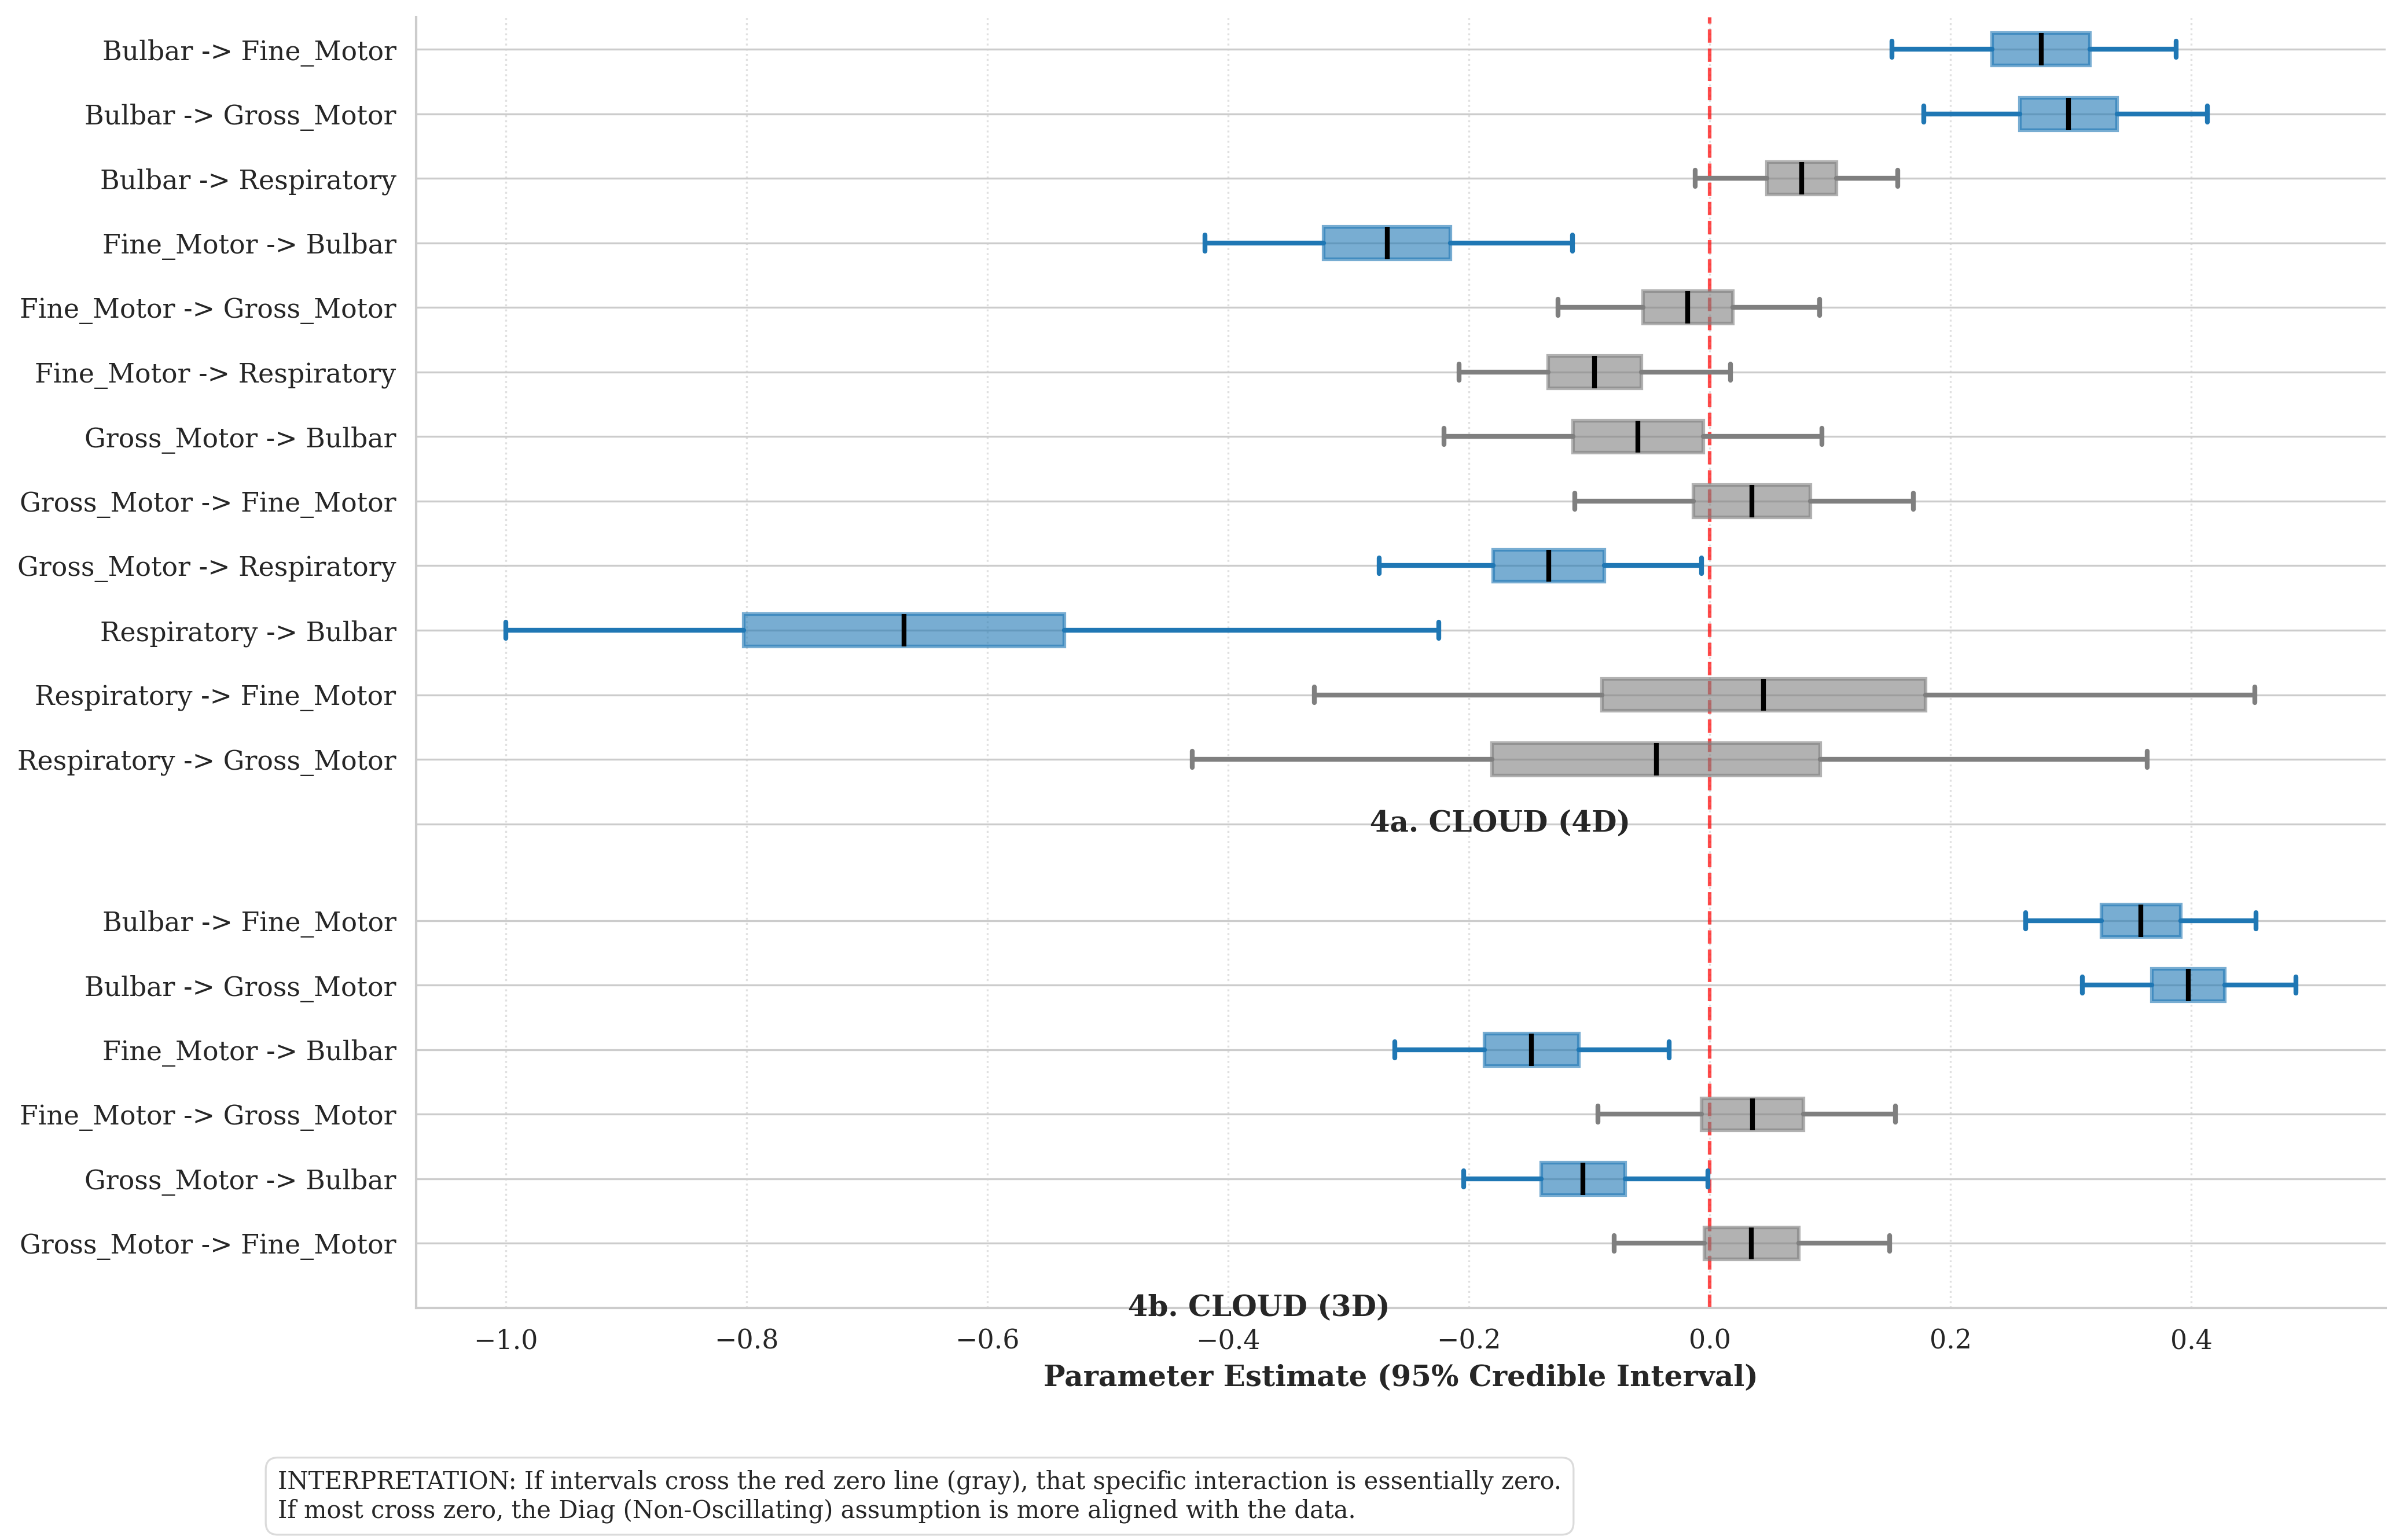

In [14]:
# Set global publication rcParams to ensure standard formatting
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

print("=== VERIFYING LATENT OSCILLATION ASSUMPTIONS ===")

# Define your files (We only need to check the models that ALLOW oscillations)
MCMC_FILES = {
    '4a. CLOUD (4D)': "../raw_results/results_S1_dahlou_ncp_cov_run1.csv",
    '4b. CLOUD (3D)': "../raw_results/results_S1_dahlou_ncp_cov_3d_run1.csv"
}

domains = {
    0: 'Bulbar',
    1: 'Fine_Motor',
    2: 'Gross_Motor',
    3: 'Respiratory'
}

# 1. Extract Off-Diagonal Gamma Parameters
results = []

for model_name, path in MCMC_FILES.items():
    try:
        df_mcmc = pd.read_csv(path)
        is_3d = '3D' in model_name
        dim = 3 if is_3d else 4
        
        # Look for the Gamma matrix in the summary stats
        subset = df_mcmc[df_mcmc['Parameter'].str.contains(r'^[Gg]amma\[', regex=True)]
        
        for _, r in subset.iterrows():
            idx_str = re.search(r'\[(.*?)\]', r['Parameter'])
            if not idx_str: continue
            
            idx_parts = idx_str.group(1).split(',')
            if len(idx_parts) == 2:
                r_idx, c_idx = int(idx_parts[0])-1, int(idx_parts[1])-1
                
                # Only keep OFF-DIAGONAL elements within the active dimensions
                if r_idx != c_idx and r_idx < dim and c_idx < dim:
                    
                    # Check if 95% CI excludes zero
                    ci_lower = r['2.5%']
                    ci_upper = r['97.5%']
                    is_significant = (ci_lower > 0) or (ci_upper < 0)
                    
                    interaction_name = f"{domains[c_idx]} -> {domains[r_idx]}"
                    
                    results.append({
                        'Model': model_name,
                        'Interaction': interaction_name,
                        'Estimate': r['Estimate'],
                        'Lower_CI': ci_lower,
                        'Upper_CI': ci_upper,
                        'Significant': is_significant
                    })
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

df_results = pd.DataFrame(results)

# 2. Terminal Output for Quick Verification
print("\n--- SIGNIFICANCE OF OFF-DIAGONAL INTERACTIONS (OSCILLATION DRIVERS) ---")
print("If these cross 0.0, the data supports the NON-OSCILLATING (Diagonal) assumption.\n")
for model in df_results['Model'].unique():
    print(f"[{model}]")
    subset = df_results[df_results['Model'] == model]
    sig_count = 0
    for _, r in subset.iterrows():
        sig_marker = "***" if r['Significant'] else ""
        if r['Significant']: sig_count += 1
        print(f"  {r['Interaction']:<30} | Est: {r['Estimate']:>6.3f} | 95% CI: [{r['Lower_CI']:>6.3f}, {r['Upper_CI']:>6.3f}] {sig_marker}")
    print(f"  -> {sig_count} out of {len(subset)} off-diagonal parameters are statistically significant.\n")


# 3. Generate Forest Plot for Visual Verification (Box Plot Style)
fig, ax = plt.subplots(figsize=(14, max(6, len(df_results) * 0.5)))

# Draw the Zero-Line (The Non-Oscillating Baseline)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, zorder=1, alpha=0.7)

# Plot parameters
y_ticks = []
y_labels = []
y_pos = 0

for model in reversed(df_results['Model'].unique()):
    subset = df_results[df_results['Model'] == model].sort_values('Interaction', ascending=False)
    
    # Add a header for the model
    y_pos += 1
    
    # Calculate text position (x-axis) dynamically to align correctly
    xlim_min = ax.get_xlim()[0]
    text_x = xlim_min if xlim_min < 0 else -0.5
    ax.text(text_x, y_pos, f"  {model}", fontweight='bold', fontsize=12, verticalalignment='center')
    
    y_ticks.append(y_pos)
    y_labels.append("")
    
    for _, r in subset.iterrows():
        y_pos += 1
        color = '#1f77b4' if r['Significant'] else '#7f7f7f' # Blue if significant, gray if not
        
        est = r['Estimate']
        lower = r['Lower_CI']
        upper = r['Upper_CI']
        
        # Approximate standard error to define the 50% CI box edges
        se = (upper - lower) / (2 * 1.96)
        
        bxp_stat = [{
            'med': est,
            'q1': est - 0.674 * se,
            'q3': est + 0.674 * se,
            'whislo': lower,
            'whishi': upper
        }]
        
        # Draw the individual box plot at the specific y_pos
        ax.bxp(
            bxp_stat,
            positions=[y_pos],
            vert=False,
            showfliers=False,
            widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=color, color=color, alpha=0.6, linewidth=1.5),
            capprops=dict(color=color, linewidth=2),
            whiskerprops=dict(color=color, linewidth=2),
            medianprops=dict(color='black', linewidth=2)
        )
        
        y_ticks.append(y_pos)
        y_labels.append(r['Interaction'])
        
    y_pos += 0.5 # Add a small gap between models

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Parameter Estimate (95% Credible Interval)")
# ax.set_title("Verification of Oscillating Assumption: Do Domains Truly Interact?")

# Clean up top and right spines for a publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

# Highlight interpretation
plt.figtext(0.12, 0.02, "INTERPRETATION: If intervals cross the red zero line (gray), that specific interaction is essentially zero.\nIf most cross zero, the Diag (Non-Oscillating) assumption is more aligned with the data.", fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.08, 1, 1])

# Save outputs
try:
    save_multiformat('Fig_I_Covariate 4D VS 3D_Forest')
except NameError:
    pass # Bypass if the function isn't defined in this script context

print("\nGenerated 'Fig_I_Assumption_Verification' successfully.")


Computing Posterior Predictive P-values & Clinical Equivalence (1,000 Simulations)...
 -> Running vectorized simulation engine for 1000 iterations...
 -> Saved formal metrics to 'Table_1_PPP_Clinical_Equivalence.csv'
 -> Generated 'Fig_P_Equivalence_Margin' successfully.


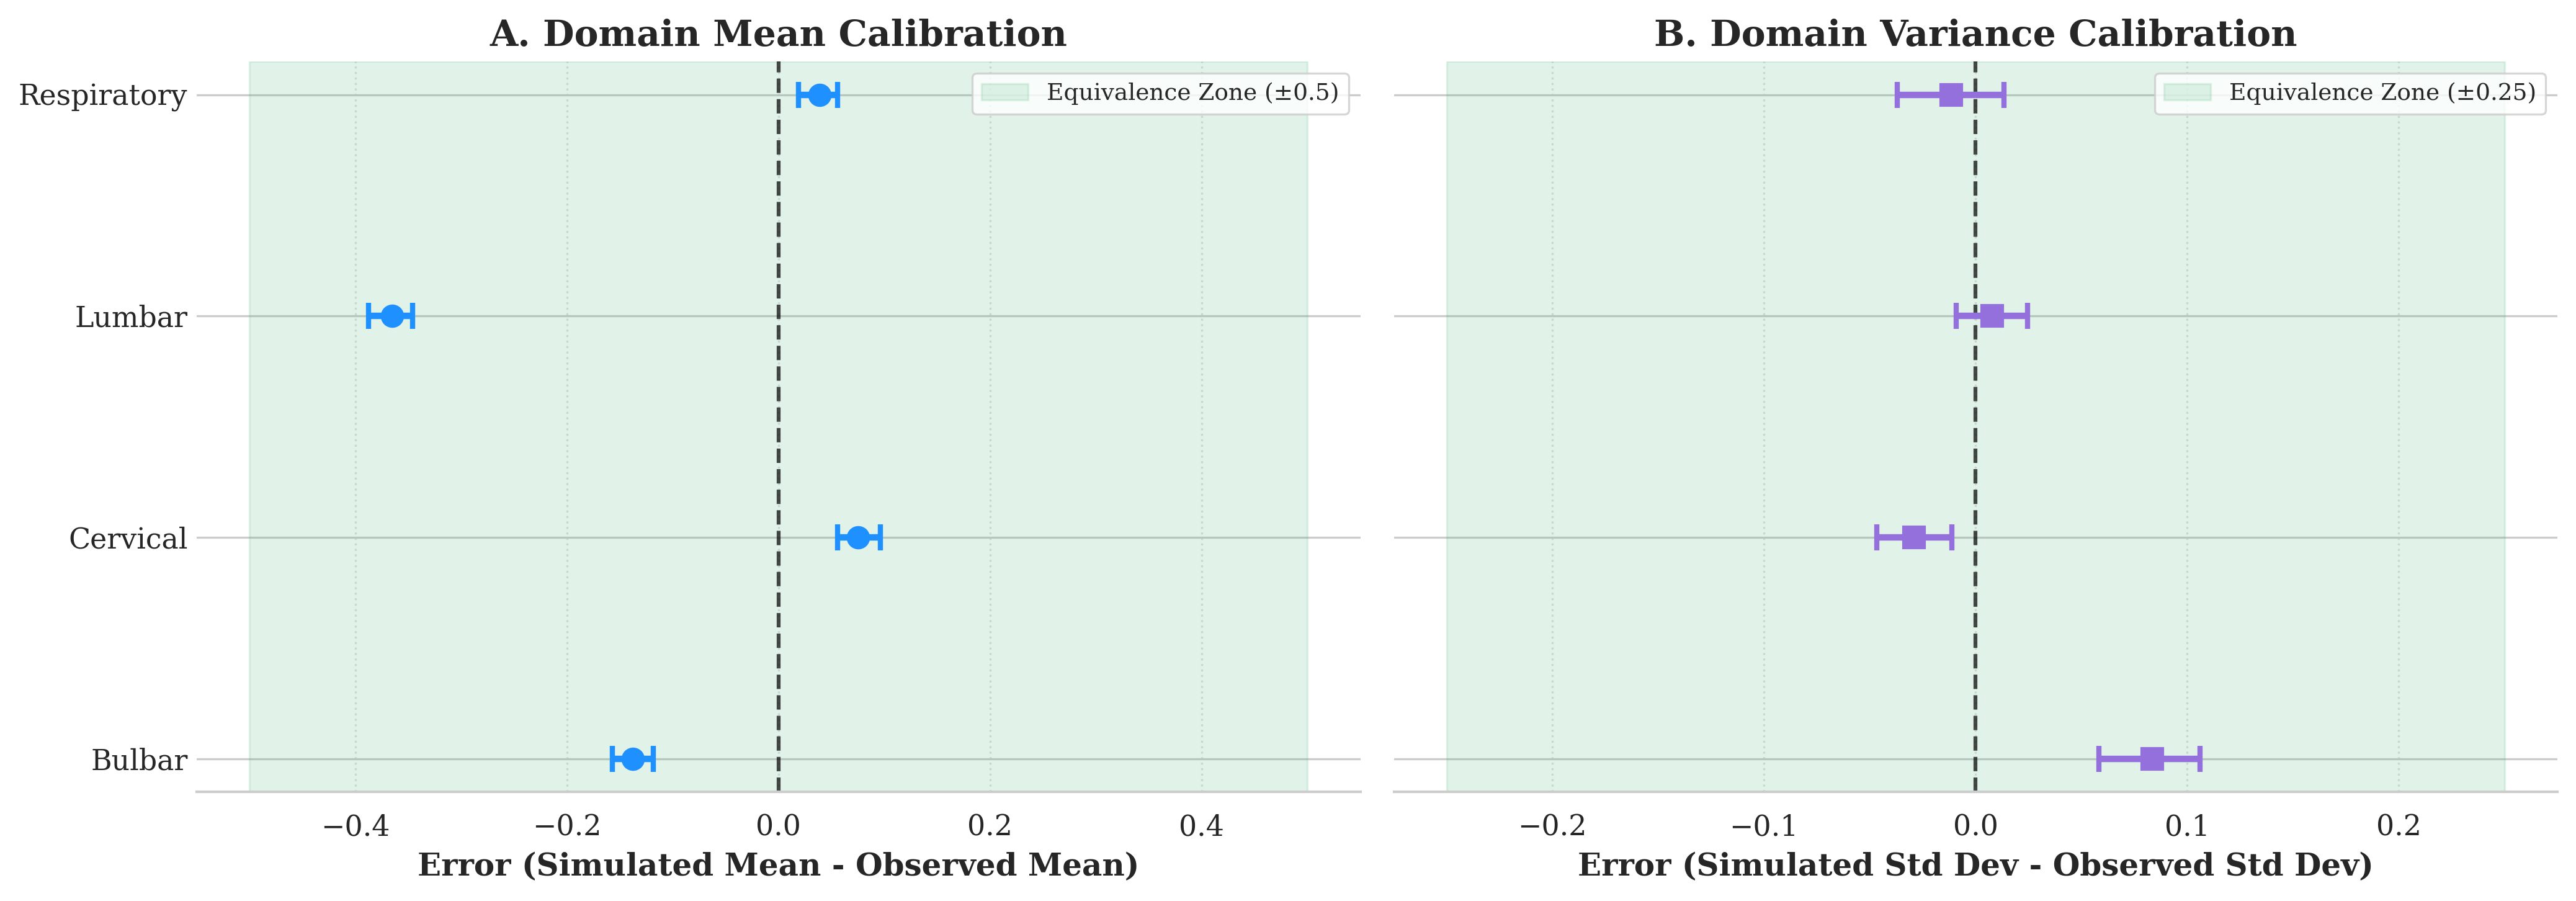

In [15]:
# ==========================================
# 11. POSTERIOR PREDICTIVE CHECKS: CLINICAL EQUIVALENCE & CSV EXPORT
# ==========================================

# 1. Set standard publication styling for the plot
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'font.family': 'serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

print("\nComputing Posterior Predictive P-values & Clinical Equivalence (1,000 Simulations)...")

model_name = '4. CLOUD' 
df_mcmc = mcmc_dfs[model_name]

# 1. Precompute the probability matrix
N_pat = len(df)
P_matrix = np.zeros((N_pat, 12, 5))

from scipy.special import expit # Ensure expit is imported if not already at the top of your script

for i in range(N_pat):
    for d, items in domain_idx_full.items():
        for k in items:
            eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
            p = [expit(1.0 * (eta - th)) for th in theta[k]]
            p_cat = [1.0-p[0], p[0]-p[1], p[1]-p[2], p[2]-p[3], p[3]]
            P_matrix[i, k, :] = np.clip(p_cat, 0, 1) / np.sum(np.clip(p_cat, 0, 1))

# Vectorized simulation setup
cumsum_P = np.cumsum(P_matrix, axis=2)
n_sims = 1000

sim_means = np.zeros((n_sims, 4))
sim_stds = np.zeros((n_sims, 4))

obs_means = np.zeros(4)
obs_stds = np.zeros(4)
for d, items in domain_idx_full.items():
    obs_domain_scores = actual_sc[:, items].sum(axis=1)
    obs_means[d] = np.mean(obs_domain_scores)
    obs_stds[d] = np.std(obs_domain_scores)

# 2. Run 1,000 Simulations
print(f" -> Running vectorized simulation engine for {n_sims} iterations...")
for s in range(n_sims):
    U = np.random.rand(N_pat, 12, 1)
    sim_Y = (U > cumsum_P).sum(axis=2) 
    
    for d, items in domain_idx_full.items():
        sim_domain_scores = sim_Y[:, items].sum(axis=1)
        sim_means[s, d] = np.mean(sim_domain_scores)
        sim_stds[s, d] = np.std(sim_domain_scores)

# 3. Export Formal CSV Table
domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']
results_list = []

for d in range(4):
    sim_m_avg = np.mean(sim_means[:, d])
    sim_s_avg = np.mean(sim_stds[:, d])
    
    results_list.append({
        'Domain': domain_labels[d],
        'Observed_Mean': obs_means[d],
        'Simulated_Mean': sim_m_avg,
        'Abs_Error_Mean': abs(obs_means[d] - sim_m_avg),
        'PPP_Mean': np.mean(sim_means[:, d] >= obs_means[d]),
        'Observed_Std': obs_stds[d],
        'Simulated_Std': sim_s_avg,
        'Abs_Error_Std': abs(obs_stds[d] - sim_s_avg),
        'PPP_Std': np.mean(sim_stds[:, d] >= obs_stds[d])
    })

df_ppp_results = pd.DataFrame(results_list)
df_ppp_results.to_csv("Table_1_PPP_Clinical_Equivalence.csv", index=False)
print(" -> Saved formal metrics to 'Table_1_PPP_Clinical_Equivalence.csv'")

# ==========================================
# 4. Generate Clinical Equivalence Margin Plot
# ==========================================

# Define the acceptable margins of error
EQUIVALENCE_MARGIN_MEAN = 0.5 
EQUIVALENCE_MARGIN_STD = 0.25

# Calculate the differences (Simulated - Observed)
diff_means = sim_means - obs_means
diff_stds = sim_stds - obs_stds

# Setup the 1x2 Equivalence Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
# fig.suptitle("Posterior Predictive Check: Clinical Equivalence Margin", fontweight='bold', fontsize=16, y=1.05)

y_positions = np.arange(len(domain_labels))

# --- Panel A: Mean Equivalence ---
ax_mean = axes[0]
ax_mean.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7) # Perfect match line
ax_mean.axvspan(-EQUIVALENCE_MARGIN_MEAN, EQUIVALENCE_MARGIN_MEAN, color='mediumseagreen', alpha=0.15, label=f'Equivalence Zone (±{EQUIVALENCE_MARGIN_MEAN})')

for d in range(4):
    # Calculate 95% interval and median
    lower, median, upper = np.percentile(diff_means[:, d], [2.5, 50, 97.5])
    
    # Plot the interval and point estimate
    ax_mean.errorbar(median, d, xerr=[[median - lower], [upper - median]], 
                     fmt='o', color='dodgerblue', markersize=8, capsize=5, elinewidth=2.5, capthick=2)

ax_mean.set_title("A. Domain Mean Calibration")
ax_mean.set_xlabel("Error (Simulated Mean - Observed Mean)")
ax_mean.set_yticks(y_positions)
ax_mean.set_yticklabels(domain_labels)
ax_mean.legend(loc='upper right')

# --- Panel B: Std Dev Equivalence ---
ax_std = axes[1]
ax_std.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax_std.axvspan(-EQUIVALENCE_MARGIN_STD, EQUIVALENCE_MARGIN_STD, color='mediumseagreen', alpha=0.15, label=f'Equivalence Zone (±{EQUIVALENCE_MARGIN_STD})')

for d in range(4):
    # Calculate 95% interval and median
    lower, median, upper = np.percentile(diff_stds[:, d], [2.5, 50, 97.5])
    
    ax_std.errorbar(median, d, xerr=[[median - lower], [upper - median]], 
                    fmt='s', color='mediumpurple', markersize=8, capsize=5, elinewidth=2.5, capthick=2)

ax_std.set_title("B. Domain Variance Calibration")
ax_std.set_xlabel("Error (Simulated Std Dev - Observed Std Dev)")
ax_std.legend(loc='upper right')

# Clean up the aesthetics
for ax in axes:
    ax.grid(True, axis='x', linestyle=':', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) 
    ax.tick_params(axis='y', length=0)   

plt.tight_layout()

# Save outputs
try:
    save_multiformat("Fig_P_Equivalence_Margin")
except NameError:
    pass

print(" -> Generated 'Fig_P_Equivalence_Margin' successfully.")

In [16]:
def extract_and_save_parameters(df, output_filename='filtered_mcmc_parameters.csv'):
    """
    Filters an MCMC DataFrame for specific parameters, groups matrix entries 
    together, saves the result to a CSV, and returns the filtered DataFrame.
    """
    targets = [
        'lambda', 'alpha_dyn', 'theta', 
        'beta', 'Gamma', 'sigma_bk', 'rho'
    ]
    
    # Create a working copy to avoid modifying the original dataframe
    working_df = df.copy()
    
    # 1. Extract the base parameter name (e.g., 'theta[1,2]' becomes 'theta')
    working_df['base_param'] = working_df['Parameter'].str.split('[').str[0]
    
    # 2. Filter the DataFrame to only include our targets
    sub_df = working_df[working_df['base_param'].isin(targets)].copy()
    
    # 3. Sort the rows to group parameters together. 
    # Sorting by 'base_param' chunks them by parameter family.
    # Sorting by 'Parameter' orders the bracketed indices.
    # Sorting by 'Run_ID' keeps iterations of the same parameter sequential.
    sub_df = sub_df.sort_values(by=['base_param', 'Parameter', 'Run_ID'])
    sub_df["Std"] = sub_df["MCSE"] * np.sqrt(sub_df["ESS"])
    
    # 4. Drop the temporary 'base_param' column to keep your original schema clean
    sub_df = sub_df.drop(columns=['base_param'])
    
    # 5. Save the final DataFrame to a CSV
    sub_df.to_csv(output_filename, index=False)
    
    return sub_df


Generated 'Fig_I_4D_Interaction_Boxplot_Horizontal.png' successfully.


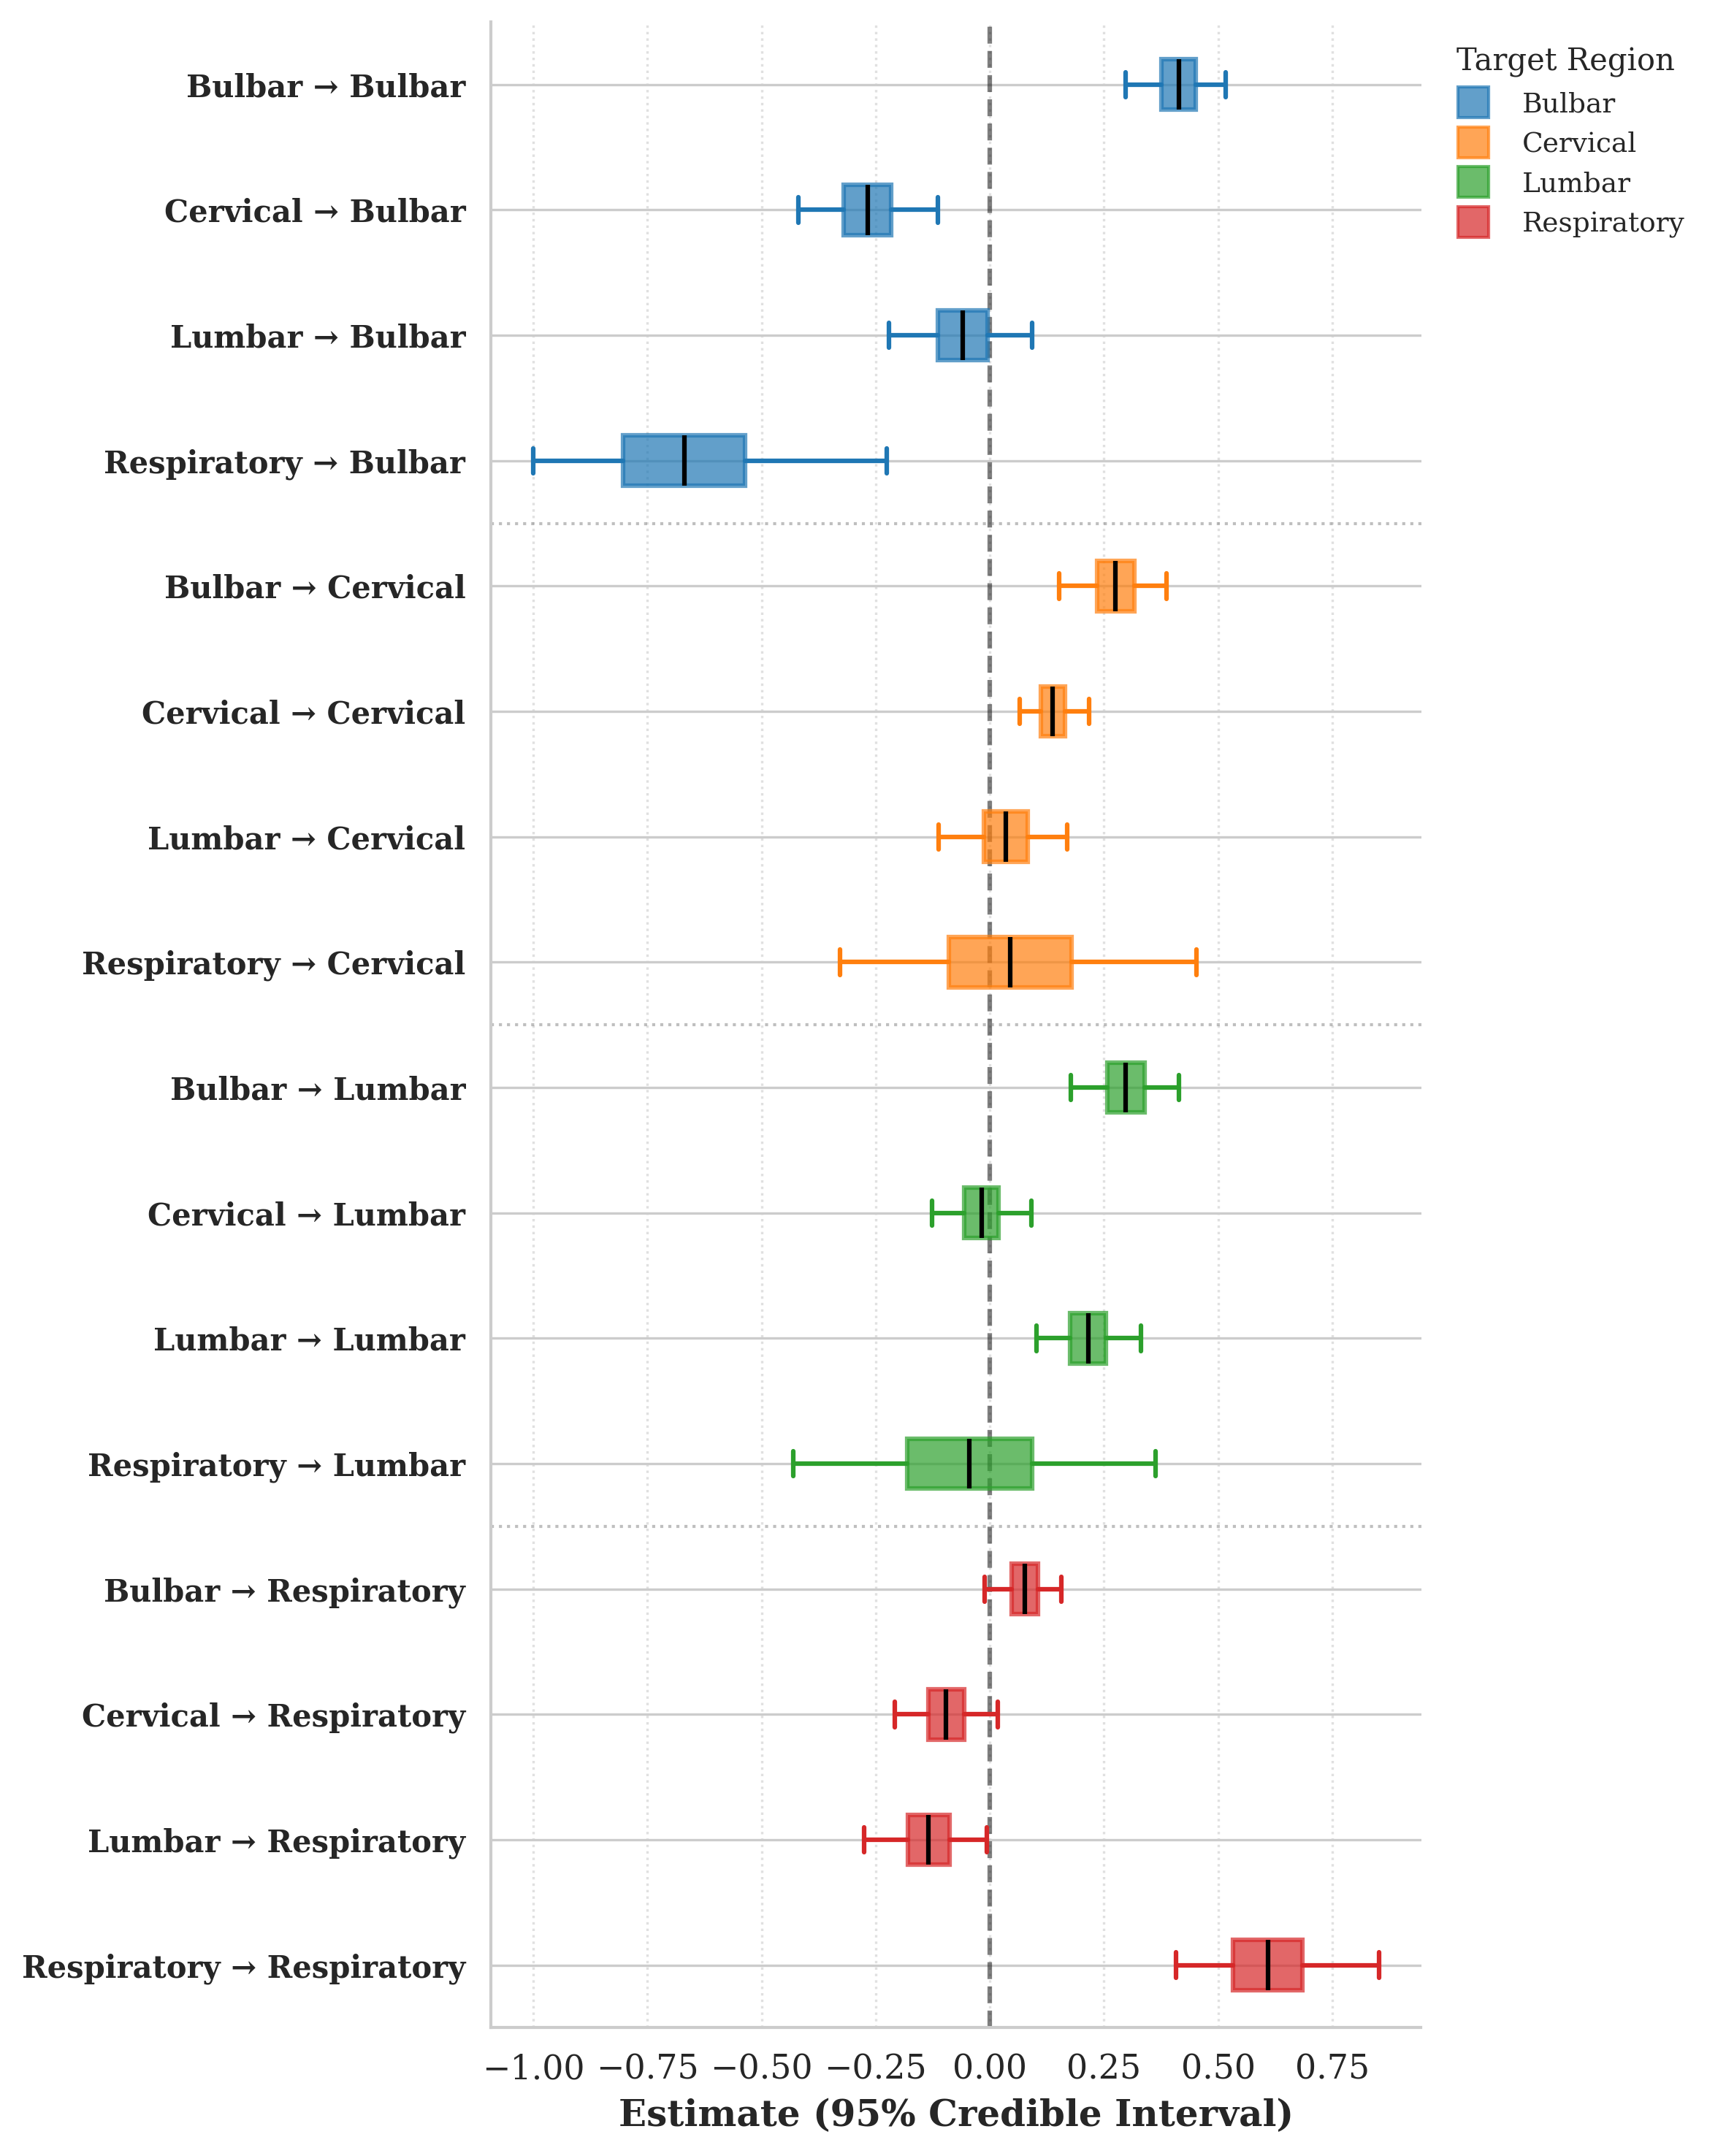

In [18]:
# Set global publication rcParams
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'font.family': 'serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

# Load and filter data
cloud_df = pd.read_csv("../raw_results/results_S1_dahlou_ncp_cov_run1.csv")

# Ensure extract_and_save_parameters is defined in your script
try:
    filtered_df = extract_and_save_parameters(cloud_df)
except NameError:
    filtered_df = cloud_df # Fallback if running as isolated snippet

gamma_df = filtered_df[filtered_df["Parameter"].str.contains("Gamma")].copy()
cloud_df = gamma_df.copy()

labels = ["Bulbar", "Cervical", "Lumbar", "Respiratory"]

def parse_param(param):
    match = re.match(r"Gamma\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

cloud_df[["i", "j"]] = cloud_df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# j → i
cloud_df["label"] = cloud_df.apply(lambda row: f"{labels[int(row['j'])]} → {labels[int(row['i'])]}", axis=1)

cloud_df = cloud_df.sort_values(["i", "j"]).reset_index(drop=True)

color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
    3: "#d62728"
}
colors = cloud_df["i"].map(color_map)

# ---- Horizontal Box Plot Setup ----
fig, ax = plt.subplots(figsize=(8, 10))  

y_pos = range(len(cloud_df))

# Reference line at 0 (drawn first so it sits behind the boxes)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, zorder=1)

# Draw individual horizontal box plots
for idx, row in cloud_df.iterrows():
    est = row['Estimate']
    lower = row['2.5%']
    upper = row['97.5%']
    
    # Approximate standard error to define the 50% CI box edges
    se = (upper - lower) / (2 * 1.96)
    
    c = colors.iloc[idx]
    
    bxp_stat = [{
        'med': est,
        'q1': est - 0.674 * se,
        'q3': est + 0.674 * se,
        'whislo': lower,
        'whishi': upper
    }]
    
    ax.bxp(
        bxp_stat,
        positions=[idx],
        vert=False,             # Set to False for horizontal boxes
        widths=0.4,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=c, color=c, alpha=0.7, linewidth=1.5),
        capprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5),
        zorder=3
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cloud_df["label"], fontsize=10, fontweight='bold')
ax.invert_yaxis() # Invert after plotting to keep the top-to-bottom reading order

ax.set_xlabel("Estimate (95% Credible Interval)", fontsize=12, fontweight='bold')
# ax.set_title("Transition Effects Between Anatomical Regions", fontsize=14, fontweight='bold')

# Clean up axes for publication
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.6, zorder=0)

# Group separators (horizontal)
for k in range(1, 4):
    ax.axhline(k*4 - 0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

# Legend (using square markers to reflect the boxes)
handles = [
    plt.Line2D([0], [0], marker='s', markersize=10, linestyle='', color=color_map[i], label=labels[i], alpha=0.7)
    for i in range(4)
]
ax.legend(handles=handles, title="Target Region", frameon=False, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save outputs
try:
    save_multiformat("Fig_I_4D_Interaction_Boxplot_Horizontal")
except NameError:
    pass

print("Generated 'Fig_I_4D_Interaction_Boxplot_Horizontal.png' successfully.")

Generated 'Fig_I_4D_Covariate_Boxplot_Horizontal.png' successfully.


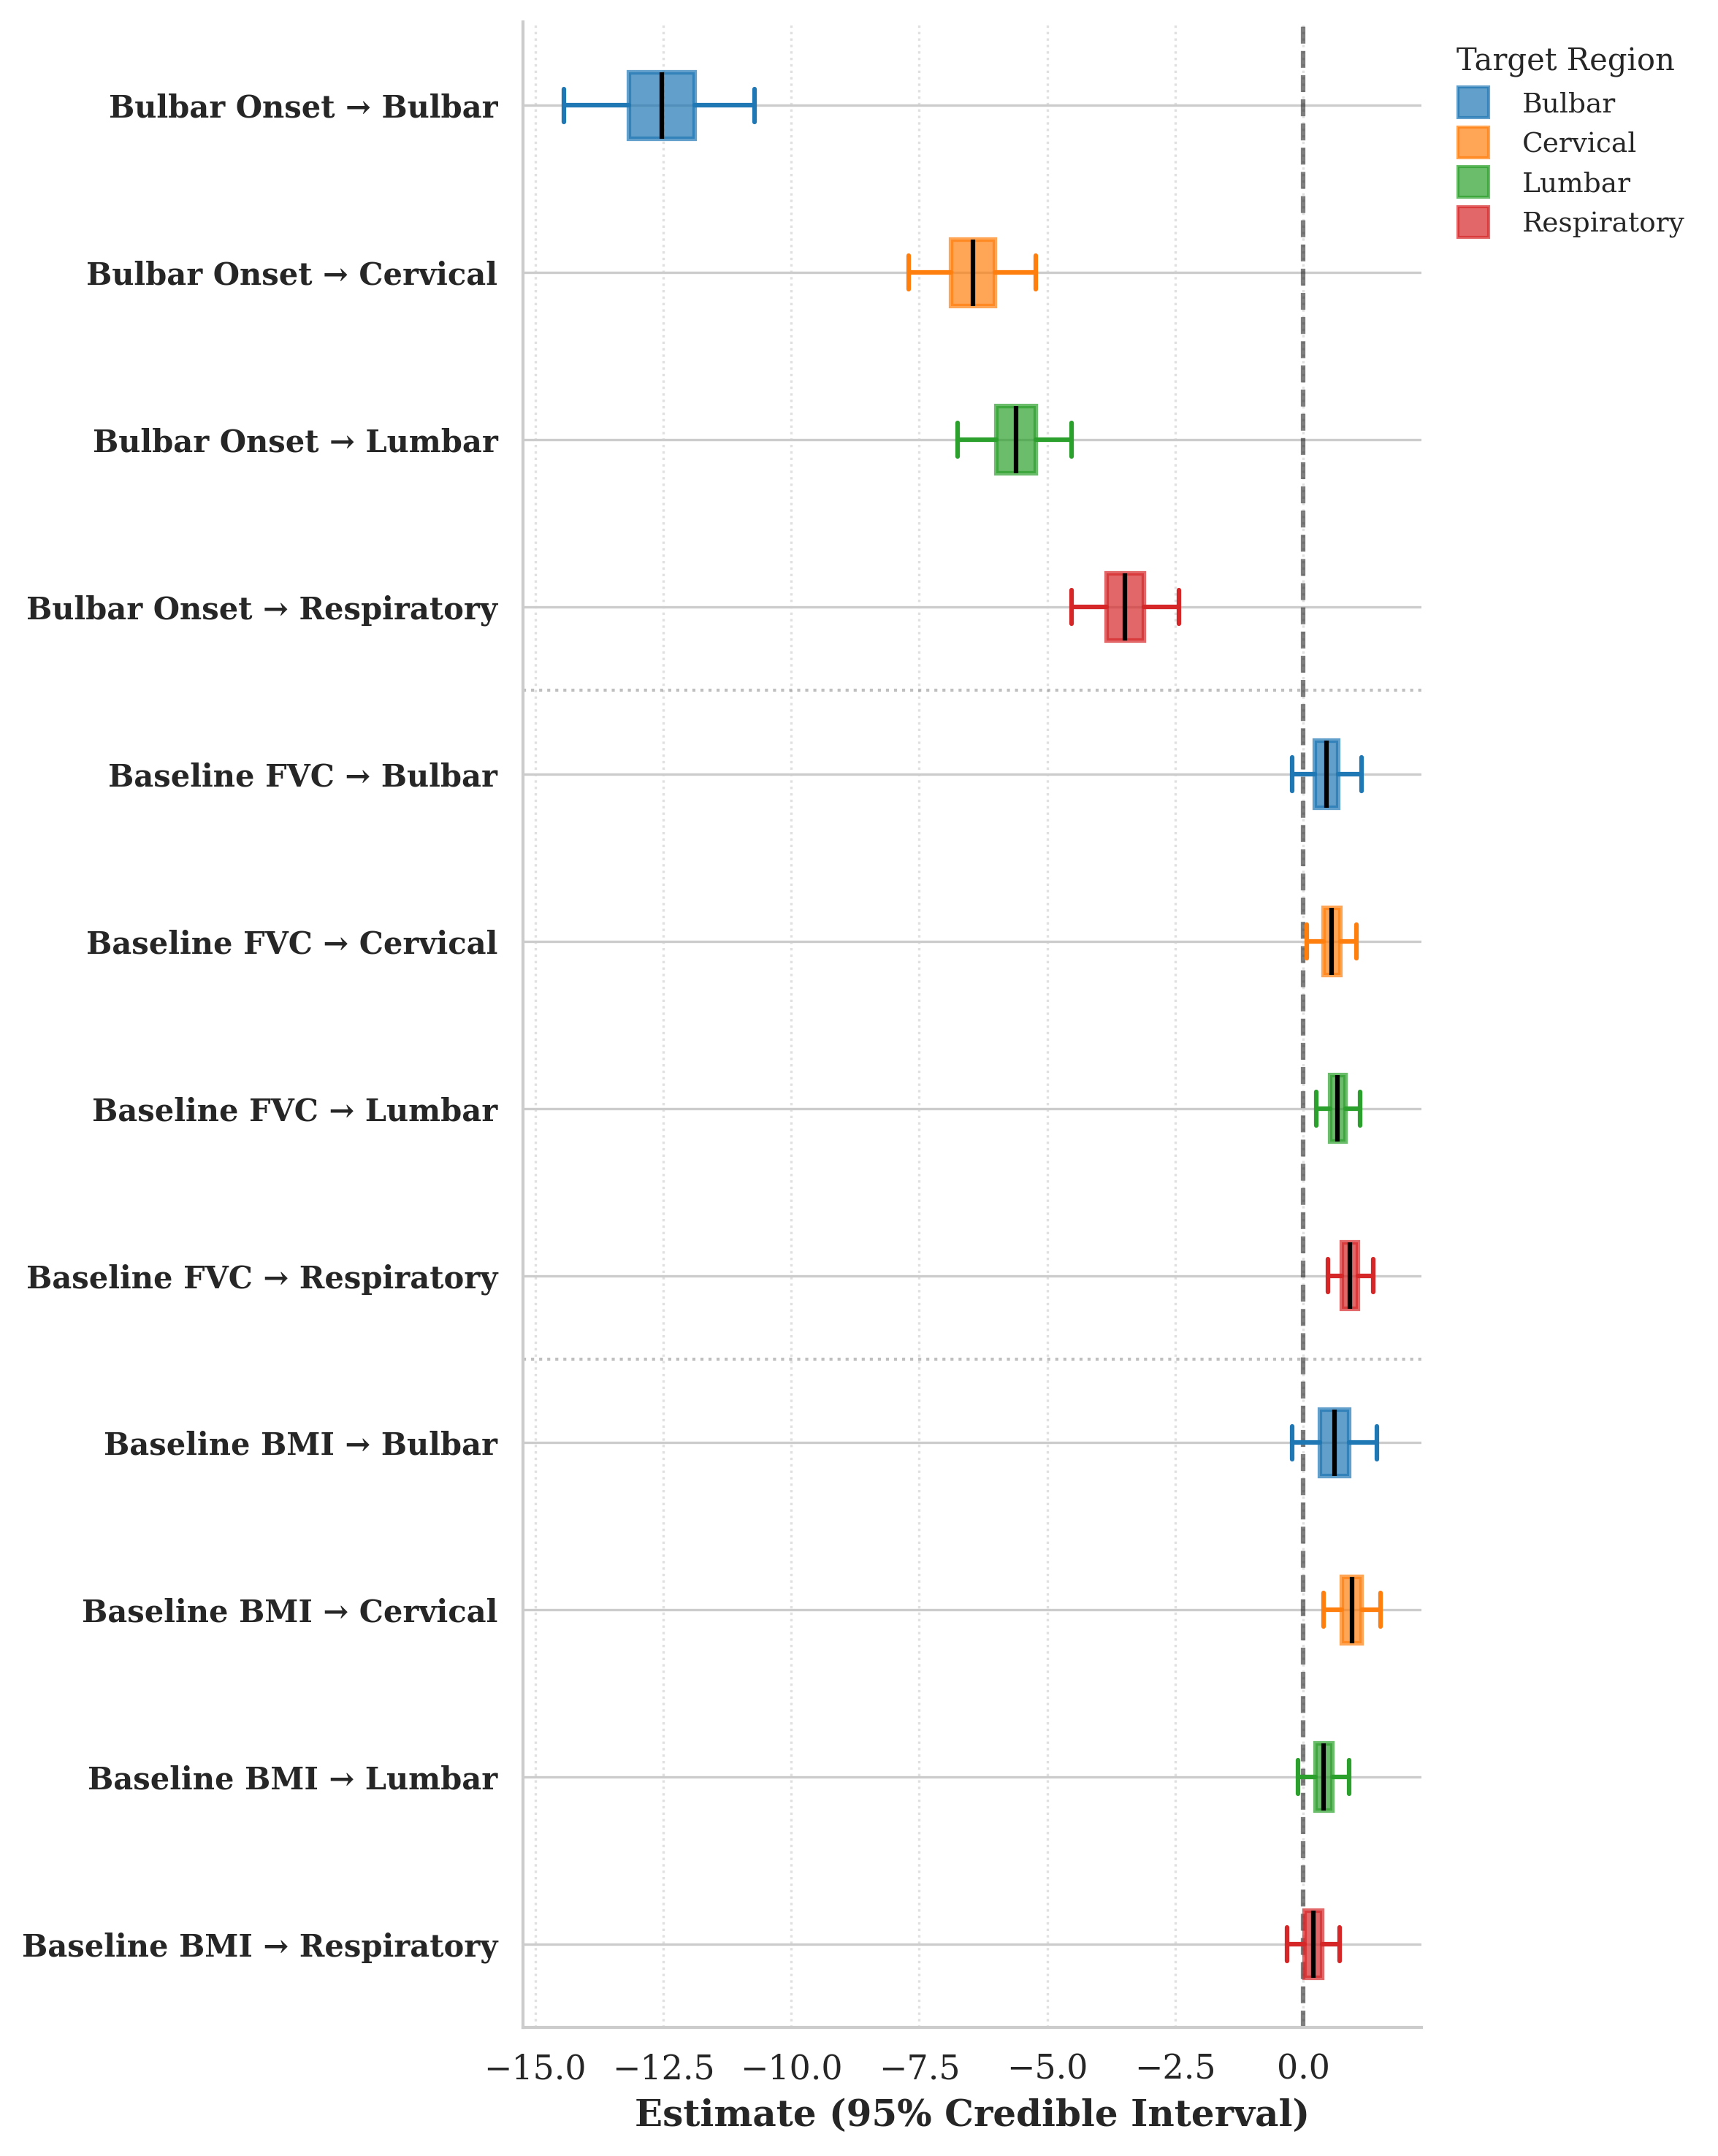

In [26]:
# Set global publication rcParams for a clean, academic aesthetic
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'font.family': 'serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

# Assuming filtered_df is defined in your broader script
cloud_alpha_df = filtered_df[filtered_df["Parameter"].str.contains("alpha")].copy()
cloud_a_df = cloud_alpha_df.copy()

i_labels = ["Bulbar", "Cervical", "Lumbar", "Respiratory"]
j_labels = ["Bulbar Onset", "Baseline FVC", "Baseline BMI"]

def parse_param(param):
    match = re.match(r"alpha_dyn\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

cloud_a_df[["i", "j"]] = cloud_a_df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# j (Covariate) → i (Target Region)
cloud_a_df["label"] = cloud_a_df.apply(lambda row: f"{j_labels[int(row['j'])]} → {i_labels[int(row['i'])]}", axis=1)

cloud_a_df = cloud_a_df.sort_values(["j", "i"]).reset_index(drop=True)

color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
    3: "#d62728"
}
colors = cloud_a_df["i"].map(color_map)

# ---- Set to identical figsize ----
fig, ax = plt.subplots(figsize=(8, 10)) 

y_pos = range(len(cloud_a_df))

# Reference line at 0 (drawn first so it sits behind the boxes, zorder=1)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, zorder=1)

for idx, row in cloud_a_df.iterrows():
    est = row['Estimate']
    lower = row['2.5%']
    upper = row['97.5%']
    
    # Approximate standard error to define the 50% CI box edges
    se = (upper - lower) / (2 * 1.96)
    
    c = colors.iloc[idx]
    
    bxp_stat = [{
        'med': est,
        'q1': est - 0.674 * se,
        'q3': est + 0.674 * se,
        'whislo': lower,
        'whishi': upper
    }]
    
    # Draw individual horizontal box plots
    ax.bxp(
        bxp_stat,
        positions=[idx],
        vert=False,             # Horizontal alignment
        widths=0.4,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=c, color=c, alpha=0.7, linewidth=1.5),
        capprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5),
        zorder=3
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cloud_a_df["label"], fontsize=10, fontweight='bold')
ax.invert_yaxis() # Maintain top-to-bottom reading order

ax.set_xlabel("Estimate (95% Credible Interval)", fontsize=12, fontweight='bold')
# ax.set_title("Effects of Baseline Covariates on Anatomical Regions", fontsize=14, fontweight='bold')

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.6, zorder=0)

# Group separators (splits the 3 covariate groups)
for k in range(1, 3):
    ax.axhline(k * 4 - 0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

# Legend (square markers to match box plot style)
handles = [
    plt.Line2D([0], [0], marker='s', markersize=10, linestyle='', color=color_map[i], label=i_labels[i], alpha=0.7)
    for i in range(4)
]
ax.legend(handles=handles, title="Target Region", frameon=False, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save outputs
try:
    save_multiformat("Fig_I_4D_Covariate_Boxplot_Horizontal")
except NameError:
    pass

print("Generated 'Fig_I_4D_Covariate_Boxplot_Horizontal.png' successfully.")

Generated 'Fig_I_3D_Interaction_Boxplot_Horizontal.png' successfully.


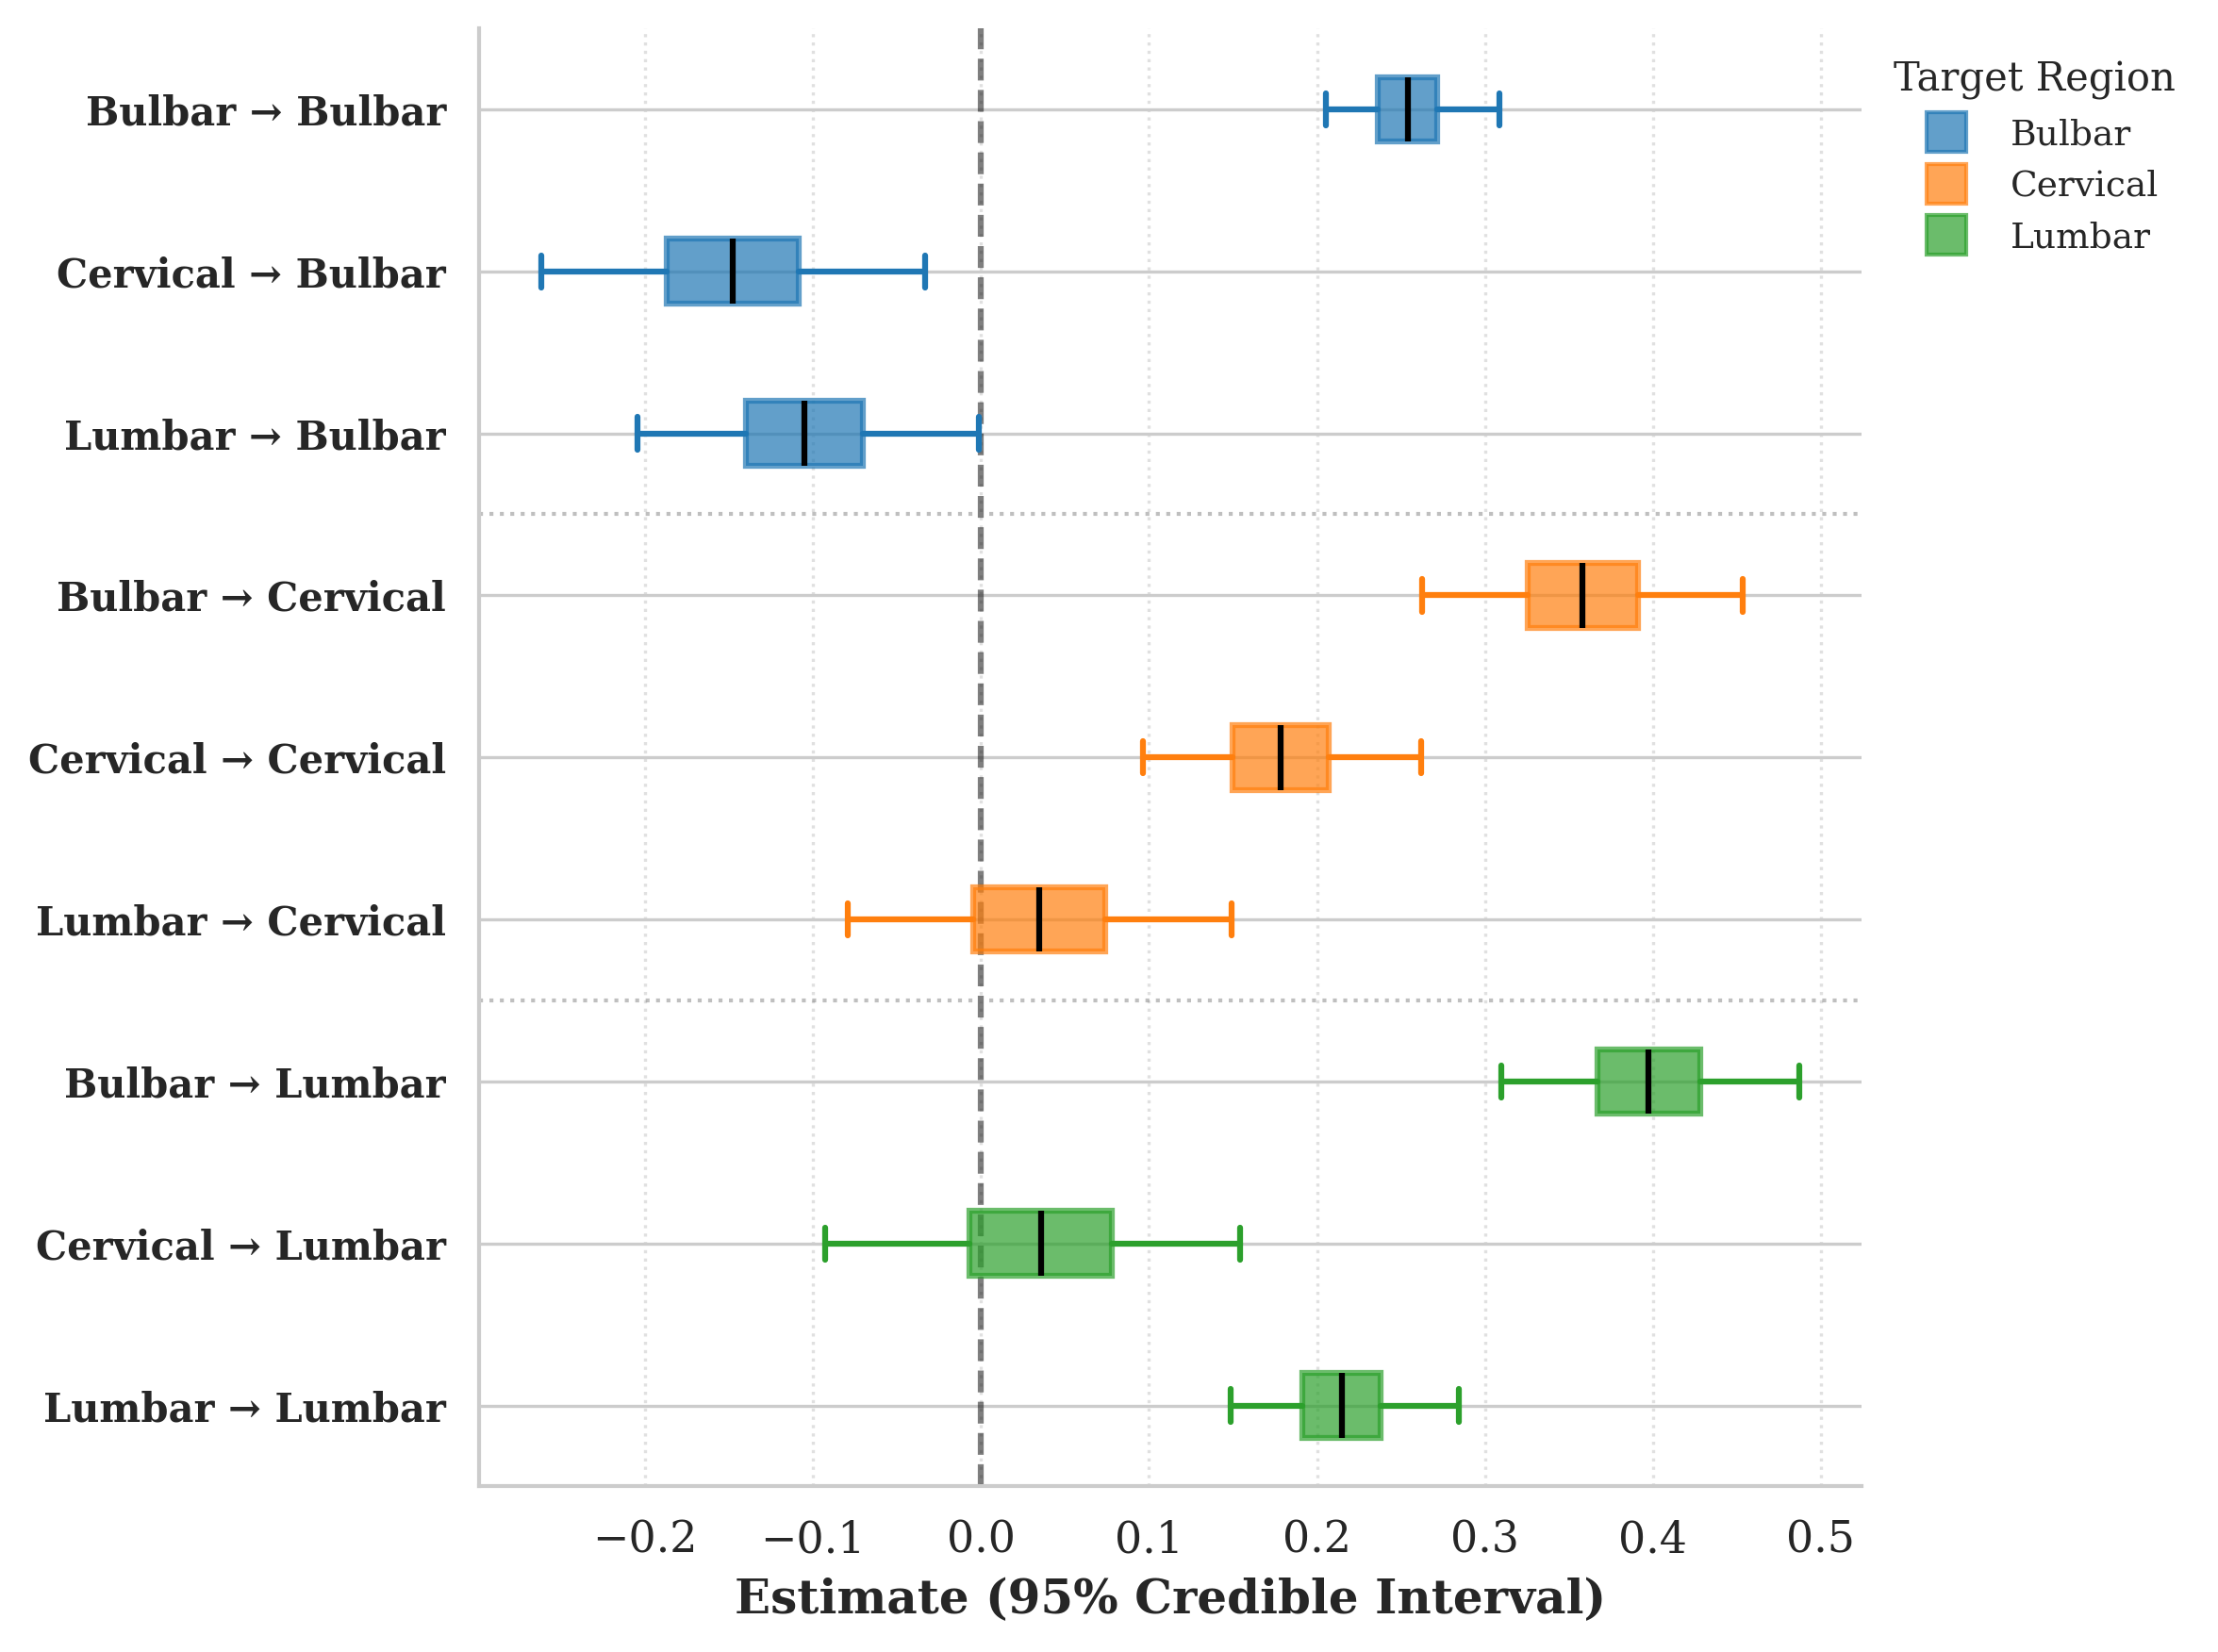

In [27]:
# Set global publication rcParams for a clean, academic aesthetic
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'font.family': 'serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

# Load the 3D model data
cloud_3d_gamma_df = pd.read_csv("../raw_results/results_S1_dahlou_ncp_cov_3d_run1.csv")

# Ensure extract_and_save_parameters is defined in your script
try:
    filtered_df = extract_and_save_parameters(cloud_3d_gamma_df, output_filename='filtered_mcmc_parameters_3d.csv')
except NameError:
    filtered_df = cloud_3d_gamma_df # Fallback if running as isolated snippet

gamma_df = filtered_df[filtered_df["Parameter"].str.contains("Gamma")].copy()
cloud_3d_gamma_df = gamma_df.copy()

labels = ["Bulbar", "Cervical", "Lumbar"]

def parse_param(param):
    match = re.match(r"Gamma\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

cloud_3d_gamma_df[["i", "j"]] = cloud_3d_gamma_df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# j (Source) → i (Target Region)
cloud_3d_gamma_df["label"] = cloud_3d_gamma_df.apply(lambda row: f"{labels[int(row['j'])]} → {labels[int(row['i'])]}", axis=1)

cloud_3d_gamma_df = cloud_3d_gamma_df.sort_values(["i", "j"]).reset_index(drop=True)

color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c"
}
colors = cloud_3d_gamma_df["i"].map(color_map)

# ---- Horizontal Box Plot Setup (3D Model) ----
fig, ax = plt.subplots(figsize=(8, 6)) 

y_pos = range(len(cloud_3d_gamma_df))

# Reference line at 0 (drawn first so it sits behind the boxes, zorder=1)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, zorder=1)

for idx, row in cloud_3d_gamma_df.iterrows():
    est = row['Estimate']
    lower = row['2.5%']
    upper = row['97.5%']
    
    # Approximate standard error to define the 50% CI box edges
    se = (upper - lower) / (2 * 1.96)
    
    c = colors.iloc[idx]
    
    bxp_stat = [{
        'med': est,
        'q1': est - 0.674 * se,
        'q3': est + 0.674 * se,
        'whislo': lower,
        'whishi': upper
    }]
    
    # Draw individual horizontal box plots
    ax.bxp(
        bxp_stat,
        positions=[idx],
        vert=False,             # Set False for horizontal orientation
        widths=0.4,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=c, color=c, alpha=0.7, linewidth=1.5),
        capprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5),
        zorder=3
    )

# Labels
ax.set_yticks(list(y_pos))
ax.set_yticklabels(cloud_3d_gamma_df["label"], fontsize=10, fontweight='bold')
ax.invert_yaxis() # Maintain top-to-bottom reading order

# Axis titles
ax.set_xlabel("Estimate (95% Credible Interval)", fontsize=12, fontweight='bold')
# ax.set_title("Transition Effects Between Anatomical Regions (3D Model)", fontsize=14, fontweight='bold')

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.6, zorder=0)

# Group separators (horizontal, intervals of 3 for the 3D architecture)
for k in range(1, 3):
    ax.axhline(k*3 - 0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

# Legend (square markers to match box plot style)
handles = [
    plt.Line2D([0], [0], marker='s', markersize=10, linestyle='', color=color_map[i], label=labels[i], alpha=0.7)
    for i in range(3)
]
ax.legend(handles=handles, title="Target Region", frameon=False, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save outputs natively as both PNG and PDF vectors
try:
    save_multiformat("Fig_I_3D_Interaction_Boxplot_Horizontal")
except NameError:
    pass

print("Generated 'Fig_I_3D_Interaction_Boxplot_Horizontal.png' successfully.")

Generated 'Fig_I_3D_Covariate_Boxplot_Horizontal.png' successfully.


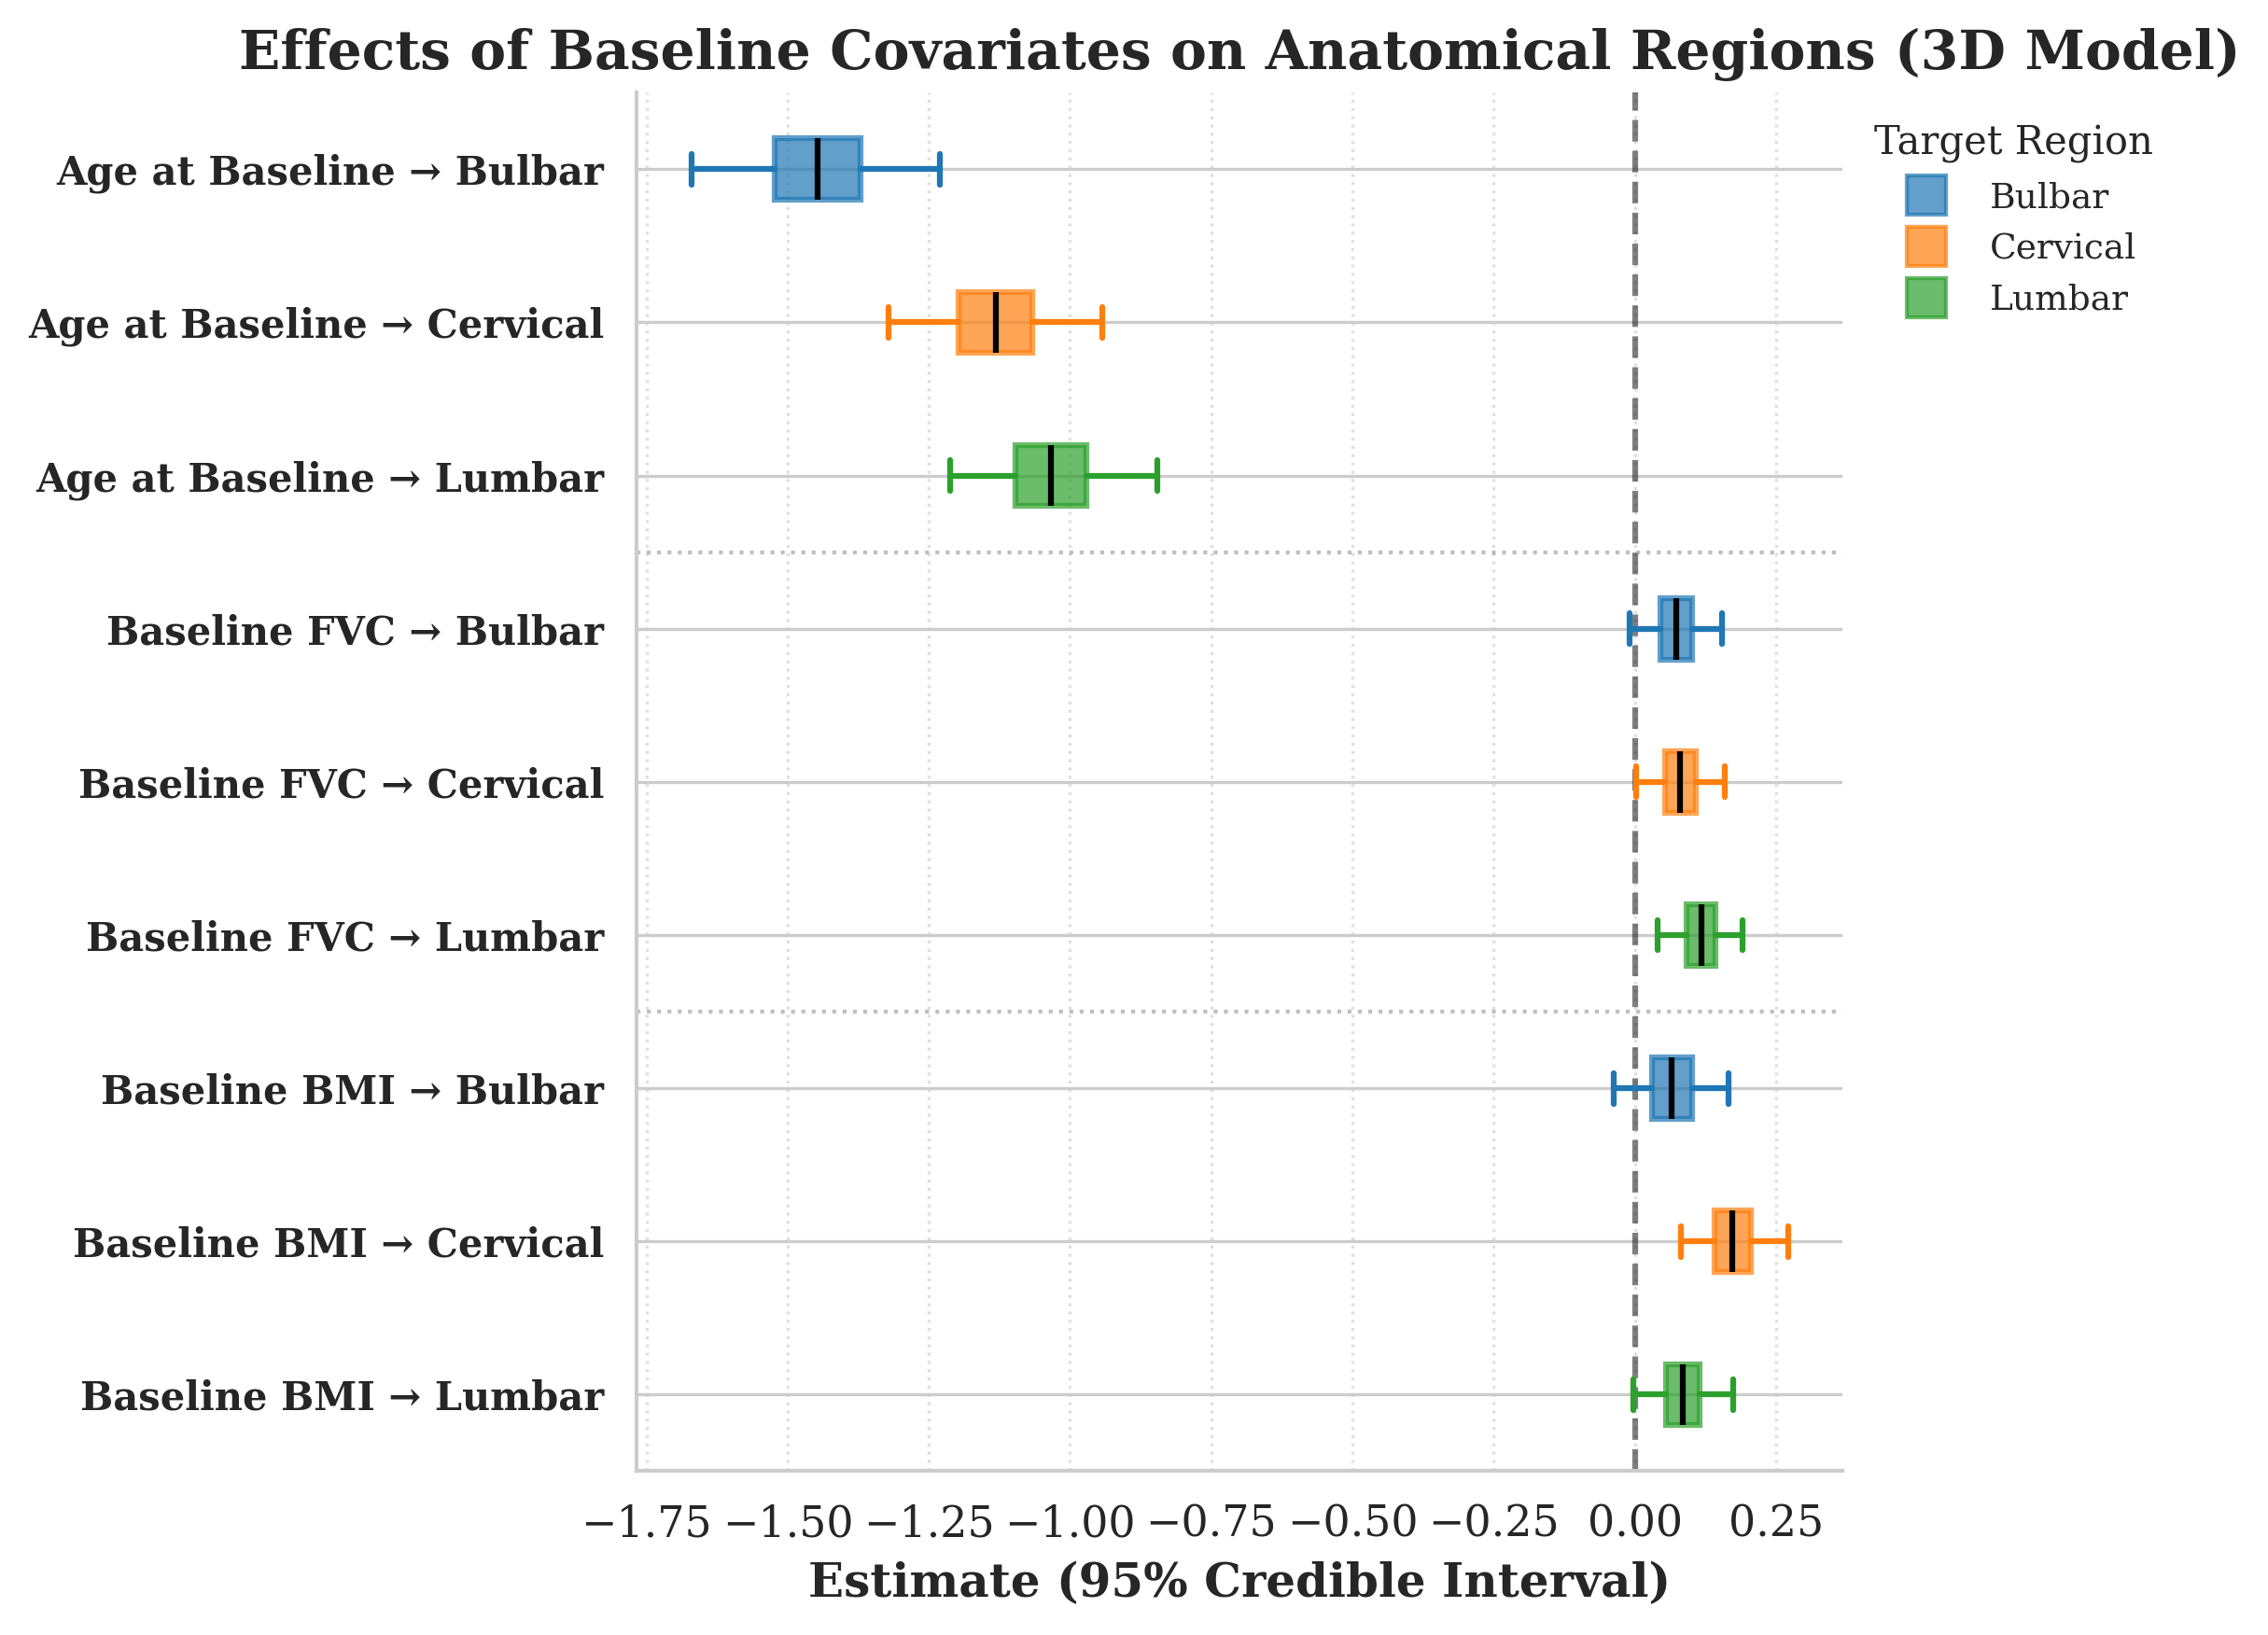

In [28]:
# Set global publication rcParams for a clean, academic aesthetic
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'font.family': 'serif',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

# Assuming filtered_df is defined in your broader script
cloud_3d_alpha_df = filtered_df[filtered_df["Parameter"].str.contains("alpha")].copy()
cloud_3d_a_df = cloud_3d_alpha_df.copy()

i_labels = ["Bulbar", "Cervical", "Lumbar"]
j_labels = ["Age at Baseline", "Baseline FVC", "Baseline BMI"]

def parse_param(param):
    match = re.match(r"alpha_dyn\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

cloud_3d_a_df[["i", "j"]] = cloud_3d_a_df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# Generate label: j -> i
cloud_3d_a_df["label"] = cloud_3d_a_df.apply(lambda row: f"{j_labels[int(row['j'])]} → {i_labels[int(row['i'])]}", axis=1)

# Sort by j first (to group by baseline covariates), then by i
cloud_3d_a_df = cloud_3d_a_df.sort_values(["j", "i"]).reset_index(drop=True)

# Define coloring scheme by 'i'
color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c"
}
colors = cloud_3d_a_df["i"].map(color_map)

# ---- Horizontal Box Plot Setup (3D Model) ----
fig, ax = plt.subplots(figsize=(8, 6)) 

y_pos = range(len(cloud_3d_a_df))

# Reference line at 0 (drawn first so it sits behind the boxes, zorder=1)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, zorder=1)

for idx, row in cloud_3d_a_df.iterrows():
    est = row['Estimate']
    lower = row['2.5%']
    upper = row['97.5%']
    
    # Approximate standard error to define the 50% CI box edges
    se = (upper - lower) / (2 * 1.96)
    
    c = colors.iloc[idx]
    
    bxp_stat = [{
        'med': est,
        'q1': est - 0.674 * se,
        'q3': est + 0.674 * se,
        'whislo': lower,
        'whishi': upper
    }]
    
    # Draw individual horizontal box plots
    ax.bxp(
        bxp_stat,
        positions=[idx],
        vert=False,             # Horizontal alignment
        widths=0.4,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=c, color=c, alpha=0.7, linewidth=1.5),
        capprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5),
        zorder=3
    )

# Format y-axis ticks
ax.set_yticks(list(y_pos))
ax.set_yticklabels(cloud_3d_a_df["label"], fontsize=10, fontweight='bold')
ax.invert_yaxis()  # Puts the first item at the top

# Axis labels and title
ax.set_xlabel("Estimate (95% Credible Interval)", fontsize=12, fontweight='bold')
ax.set_title("Effects of Baseline Covariates on Anatomical Regions (3D Model)", fontsize=14, fontweight='bold')

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis='x', linestyle=':', alpha=0.6, zorder=0)

# Add horizontal grouping separators (splits the 3 covariate groups)
for k in range(1, 3):
    ax.axhline(k * 3 - 0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

# Add Legend (square markers to match box plot style)
handles = [
    plt.Line2D([0], [0], marker='s', markersize=10, linestyle='', color=color_map[i], label=i_labels[i], alpha=0.7)
    for i in range(3)
]
# Move legend outside the plot area
ax.legend(handles=handles, title="Target Region", frameon=False, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save outputs natively as both PNG and PDF vectors
try:
    save_multiformat("Fig_I_3D_Covariate_Boxplot_Horizontal")
except NameError:
    pass

print("Generated 'Fig_I_3D_Covariate_Boxplot_Horizontal.png' successfully.")